# EDA NomadOptima: 5 Ciudades — Análisis Exploratorio Completo

**Ciudades:** Málaga · París · Valencia · Porto · Burdeos

**Fuentes:** Numbeo · wttr.in · OpenStreetMap · Google Places · Speedtest

**Objetivo:** Entender la calidad de los datos, diferencias entre ciudades
y qué features aportarán más información al modelo de ranking.


# 0. Setup

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)

COLORS = {
    "Málaga":   "#2E86AB",
    "París":    "#E67E22",
    "Valencia": "#27AE60",
    "Porto":    "#8E44AD",
    "Burdeos":  "#C0392B",
}
COLOR_LIST = list(COLORS.values())

# Carga dinamica desde cities_raw.json
with open("../data/raw/cities_raw.json", encoding="utf-8") as f:
    cities_raw = json.load(f)

# Renombrar claves a nombres display con acento
KEY_MAP = {"Malaga": "Málaga", "Paris": "París",
           "Valencia": "Valencia", "Porto": "Porto", "Bordeaux": "Burdeos"}
cities_raw = {KEY_MAP.get(k, k): v for k, v in cities_raw.items()}

print(f"Ciudades cargadas: {list(cities_raw.keys())}")


Ciudades cargadas: ['Málaga', 'París', 'Valencia', 'Porto', 'Burdeos']


**OBSERVACIONES:**
- Cargamos datos desde los JSONs generados por fetch_cities.py
- Cada ciudad tiene 7 fuentes de datos
- seaborn mejora el aspecto visual de los gráficos de matplotlib

**ANOTACIONES:**
- `warnings.filterwarnings('ignore')` evita mensajes de advertencia que no son errores
- `sns.set_theme()` aplica estilo visual global a todos los gráficos del notebook

---
# Paso 1: Entender el problema y qué representa cada fila

**¿Qué representa una fila?**
En nuestro dataset **cada fila es una ciudad**. Las columnas son las features (características) de esa ciudad.

**¿Qué queremos predecir?**
La **relevancia** de cada ciudad para un perfil de usuario concreto (0=irrelevante, 3=muy relevante).
Eso es el **target** (variable objetivo) del modelo LightGBM.

**¿Hay riesgo de data leakage?**
No — todas las features de ciudad son conocidas antes de hacer la predicción.

**Fuentes de datos:**

| Fuente | Qué mide | Nº features |
|--------|---------|-------------|
| Numbeo | Coste de vida, precios, calidad de vida | ~15 |
| wttr.in | Clima actual y previsión | ~8 |
| Wikipedia | Descripción y tipo de ciudad | ~3 |
| RestCountries | País, idioma, moneda, Schengen | ~6 |
| OpenStreetMap | Infraestructura urbana (conteos reales) | ~19 |
| Google Places | Establecimientos por categoría | ~46 |
| Speedtest | Velocidad de internet | ~4 |

---
# Paso 2: Construir el DataFrame y mirada rápida

In [2]:
def build_flat_features(city_name, data):
    """Convierte el JSON anidado de una ciudad en una fila plana del DataFrame."""
    row = {'ciudad': city_name}
    
    # Numbeo
    numbeo = data.get('numbeo', {})
    for k, v in numbeo.get('key_prices', {}).items():
        row[f'numbeo_{k}'] = v
    for k, v in numbeo.get('quality_indices', {}).items():
        row['numbeo_quality_of_life'] = v
    
    # Weather
    current = data.get('weather', {}).get('current', {})
    for k, v in current.items():
        row[f'weather_{k}'] = v
    forecast = data.get('weather', {}).get('forecast', [])
    if forecast:
        row['weather_forecast_avg_c']   = round(np.mean([d.get('avg_c', np.nan) for d in forecast]), 2)
        row['weather_forecast_sun_hrs'] = round(np.mean([d.get('sun_hours', np.nan) for d in forecast]), 2)
    
    # Country
    country = data.get('country', {})
    row['country_schengen']     = int(country.get('schengen', False))
    row['country_eu_member']    = int(country.get('eu_member', False))
    row['country_currency_eur'] = int('EUR' in country.get('currencies', []))
    row['country_n_languages']  = len(country.get('languages', []))
    row['country_esp']          = int('Spanish' in country.get('languages', []))
    row['country_fra']          = int('French'  in country.get('languages', []))
    
    # Speedtest
    spd = data.get('speedtest', {})
    row['speedtest_download_mbps'] = spd.get('fixed_download_mbps', np.nan)
    row['speedtest_upload_mbps']   = spd.get('fixed_upload_mbps', np.nan)
    row['speedtest_mobile_mbps']   = spd.get('mobile_download_mbps', np.nan)
    row['speedtest_rank_global']   = spd.get('fixed_rank_global', np.nan)
    
    # OSM
    infra = data.get('osm', {}).get('infrastructure', {})
    for k, v in infra.items():
        row[f'osm_{k}'] = v if v is not None else np.nan
    
    # Google Places
    gp_cats = data.get('google_places', {}).get('categories', {})
    for k, v in gp_cats.items():
        if isinstance(v, dict):
            row[f'gp_{k}'] = v.get('count', np.nan)
    
    return row

rows = [build_flat_features(name, data) for name, data in cities_raw.items()]
df = pd.DataFrame(rows).set_index('ciudad')
print(f'Shape: {df.shape[0]} ciudades x {df.shape[1]} features')

Shape: 5 ciudades x 94 features


rows = [build_flat_features(name, data) for name, data in cities_raw.items()]
df = pd.DataFrame(rows).set_index("ciudad")

print(f"DataFrame: {df.shape[0]} ciudades x {df.shape[1]} columnas")
print(f"Ciudades: {list(df.index)}")
df.head()


In [3]:
# Mirada rápida — ver las primeras columnas por fuente
for p in ['numbeo', 'weather', 'country', 'speedtest']:
    cols = [c for c in df.columns if c.startswith(p)]
    print(f'\n--- {p.upper()} ({len(cols)} features) ---')
    print(df[cols].T.to_string())


--- NUMBEO (11 features) ---
ciudad                     Málaga    París  Valencia    Porto  Burdeos
numbeo_rent_1br_center    1160.00  1379.27   1198.33  1099.38   796.03
numbeo_rent_1br_outside    857.54  1005.00    883.70   810.00   646.22
numbeo_meal_cheap           15.00    15.00     15.00    11.25    18.00
numbeo_meal_midrange        60.00    70.00     60.00    50.00    60.00
numbeo_coffee                2.15     4.40      2.40     2.14     3.06
numbeo_beer                  1.09     2.25      1.16     1.11     3.58
numbeo_transport_monthly    23.95    90.00     30.00    40.00    42.00
numbeo_gym_monthly          41.25    38.00     37.43    41.08    28.75
numbeo_internet_monthly     23.07    28.48     33.40    33.06    26.62
numbeo_basic_utilities     126.28   240.65    141.87   120.81   209.22
numbeo_quality_of_life     180.17   147.32    190.24   179.26   186.18

--- WEATHER (8 features) ---
ciudad                   Málaga  París Valencia  Porto   Burdeos
weather_temp_c         

**OBSERVACIONES:**
- Numbeo: `key_prices` vacío — problema del key_map (error conocido)
- Weather: datos del momento de descarga, no históricos anuales
- Country: Schengen y euro iguales en ambas — estas features no discriminan
- Speedtest: datos a nivel país, no ciudad

**DUDA:** ¿Por qué el Quality of Life de Málaga (180) es mayor que el de París (147) si París es más grande y cosmopolita?
→ El índice Numbeo está calculado por sus propios usuarios. Málaga puntúa alto en clima y bajo coste, que pesan mucho en la percepción de calidad de vida.

---
# Paso 3: Estructura y tipos de datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, Málaga to Burdeos
Data columns (total 94 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   numbeo_rent_1br_center    5 non-null      float64
 1   numbeo_rent_1br_outside   5 non-null      float64
 2   numbeo_meal_cheap         5 non-null      float64
 3   numbeo_meal_midrange      5 non-null      float64
 4   numbeo_coffee             5 non-null      float64
 5   numbeo_beer               5 non-null      float64
 6   numbeo_transport_monthly  5 non-null      float64
 7   numbeo_gym_monthly        5 non-null      float64
 8   numbeo_internet_monthly   5 non-null      float64
 9   numbeo_basic_utilities    5 non-null      float64
 10  numbeo_quality_of_life    5 non-null      float64
 11  weather_temp_c            5 non-null      float64
 12  weather_feels_like_c      5 non-null      float64
 13  weather_humidity_pct      5 non-null      float64
 14  weather_

In [5]:
# Tipos de datos
tipo_counts = df.dtypes.value_counts()
print('Tipos de datos:')
for dtype, count in tipo_counts.items():
    print(f'  {dtype}: {count} columnas')

cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_objeto    = df.select_dtypes(include=['object']).columns.tolist()
print(f'\nNúmericas: {len(cols_numericas)} | Texto: {len(cols_objeto)}')
if cols_objeto:
    print(f'  Columnas texto: {cols_objeto} ← requieren atención')

Tipos de datos:
  int64: 71 columnas
  float64: 22 columnas
  object: 1 columnas

Númericas: 93 | Texto: 1
  Columnas texto: ['weather_description'] ← requieren atención


**OBSERVACIONES:**
- Todas las columnas son numéricas — correcto para un modelo de ML
- Las booleanas (0/1) están como int64 — el modelo las puede usar directamente

**ANOTACIONES:**
- `float64` = número decimal de 64 bits
- `int64` = número entero de 64 bits
- `object` en pandas = texto (string) — si aparece en columnas numéricas es un problema a resolver

---
# Paso 4: Valores faltantes (NaN)

In [6]:
# Contar NaN por columna
nan_counts = df.isna().sum()
nan_pct    = (df.isna().mean() * 100).round(1)

df_nans = pd.DataFrame({
    'nan_count': nan_counts,
    'nan_pct':   nan_pct,
    'fuente':    [c.split('_')[0] for c in df.columns]
}).query('nan_count > 0').sort_values('nan_pct', ascending=False)

print(f'Columnas con NaN: {len(df_nans)} de {len(df.columns)} totales')
if len(df_nans) > 0:
    print(df_nans.to_string())
else:
    print('✓ Sin NaN')

Columnas con NaN: 4 de 94 totales
                         nan_count  nan_pct     fuente
speedtest_download_mbps          1     20.0  speedtest
speedtest_upload_mbps            1     20.0  speedtest
speedtest_mobile_mbps            1     20.0  speedtest
speedtest_rank_global            1     20.0  speedtest


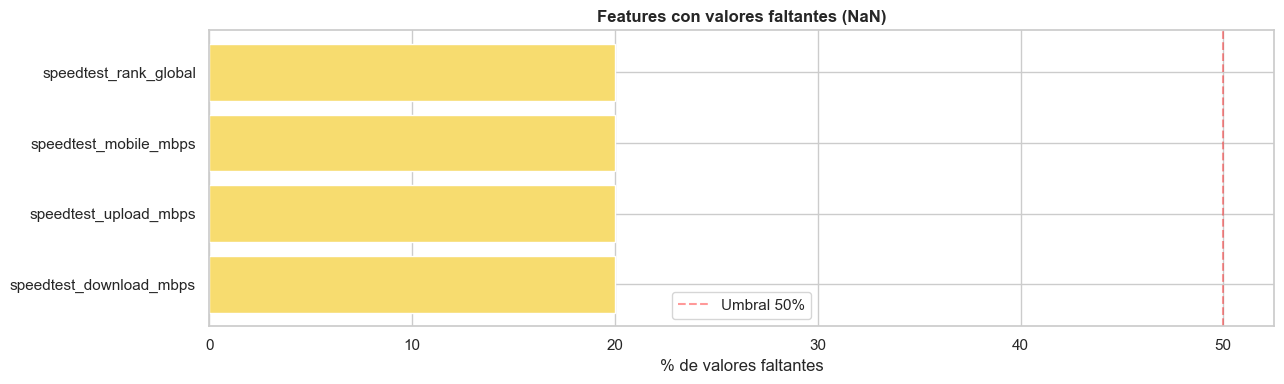

Rojo=100% NaN | Naranja=>50% | Amarillo=<50%


In [7]:
# Visualizar NaN
if len(df_nans) > 0:
    fig, ax = plt.subplots(figsize=(13, max(4, len(df_nans) * 0.35)))
    colors_nan = df_nans['nan_pct'].apply(
        lambda x: '#E74C3C' if x == 100 else '#F39C12' if x > 50 else '#F7DC6F'
    )
    ax.barh(df_nans.index, df_nans['nan_pct'], color=colors_nan, edgecolor='white')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Features con valores faltantes (NaN)', fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.4, label='Umbral 50%')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Rojo=100% NaN | Naranja=>50% | Amarillo=<50%')

**OBSERVACIONES:**
- Las features de `numbeo_key_prices` tienen 100% NaN — el key_map no hizo match
- Son features críticas: precios de alquiler, comida, transporte
- Están marcadas como **pendientes de fix** antes de entrenar el modelo

**ANOTACIONES:**
- NaN = Not a Number — estándar de pandas para valores ausentes
- No rellenamos NaN con 0 porque 0 tiene significado propio ('0 restaurantes')
- LightGBM maneja NaN nativamente — los ignora en los splits del árbol

**DECISIÓN:** Se mantienen como NaN. Se resolverán antes del entrenamiento del modelo.

---
# Paso 5: Auditoría de calidad por fuente

In [8]:
print('=' * 65)
print('AUDITORÍA DE CALIDAD POR FUENTE')
print('=' * 65)

for fuente in ['numbeo', 'weather', 'country', 'osm', 'google_places', 'speedtest']:
    print(f'\n{fuente.upper()}')
    for city_name, data in cities_raw.items():
        src = data.get(fuente, {})
        has_error = 'error' in src
        is_skip   = src.get('skipped', False)
        if has_error:
            status = f'ERROR: {src["error"][:50]}'
        elif is_skip:
            status = f'SKIP: {src.get("reason", "cadencia")}'
        else:
            status = 'OK'
        fetched = src.get('fetched_at', '?')[:10]
        print(f'  {city_name:<10} [{fetched}]  {status}')

AUDITORÍA DE CALIDAD POR FUENTE

NUMBEO
  Málaga     [2026-04-01]  OK
  París      [2026-04-01]  OK
  Valencia   [2026-04-05]  OK
  Porto      [2026-04-05]  OK
  Burdeos    [2026-04-05]  OK

WEATHER
  Málaga     [2026-04-05]  OK
  París      [2026-04-05]  OK
  Valencia   [2026-04-05]  OK
  Porto      [2026-04-05]  OK
  Burdeos    [2026-04-05]  OK

COUNTRY
  Málaga     [2026-03-20]  OK
  París      [2026-03-20]  OK
  Valencia   [2026-04-05]  OK
  Porto      [2026-04-05]  OK
  Burdeos    [2026-04-05]  OK

OSM
  Málaga     [2026-03-20]  OK
  París      [2026-03-20]  OK
  Valencia   [2026-04-05]  OK
  Porto      [2026-04-05]  OK
  Burdeos    [2026-04-05]  OK

GOOGLE_PLACES
  Málaga     [2026-04-01]  OK
  París      [2026-04-01]  OK
  Valencia   [2026-04-05]  OK
  Porto      [2026-04-05]  OK
  Burdeos    [2026-04-05]  OK

SPEEDTEST
  Málaga     [2026-03-20]  OK
  París      [2026-03-20]  OK
  Valencia   [2026-04-05]  OK
  Porto      [2026-04-05]  OK
  Burdeos    [2026-04-05]  OK


In [9]:
# Google Places: analizar cap de 20
print('=== GOOGLE PLACES: ANÁLISIS DEL CAP DE 20 ===')
print('La API devuelve máximo 20 resultados — si una categoría tiene 20, puede haber más\n')

for city_name, data in cities_raw.items():
    cats = data.get('google_places', {}).get('categories', {})
    capped = [k for k, v in cats.items() if isinstance(v, dict) and v.get('count') == 20]
    real   = [(k, v.get('count')) for k, v in cats.items()
              if isinstance(v, dict) and 0 < v.get('count', 0) < 20]
    zeros  = [k for k, v in cats.items() if isinstance(v, dict) and v.get('count', 0) == 0]
    print(f'{city_name}:')
    print(f'  Capeadas a 20 (no comparables): {len(capped)}')
    print(f'  Conteo real (<20): {real}')
    print(f'  Sin resultados (0): {zeros}')

=== GOOGLE PLACES: ANÁLISIS DEL CAP DE 20 ===
La API devuelve máximo 20 resultados — si una categoría tiene 20, puede haber más

Málaga:
  Capeadas a 20 (no comparables): 6
  Conteo real (<20): [('cycling_park', 2), ('national_park', 1), ('fine_dining', 15), ('movie_theater', 19), ('subway_station', 19), ('train_station', 18), ('amusement_park', 18), ('zoo', 7), ('bowling_alley', 7), ('pediatric_hospital', 4), ('surf_school', 1), ('tech_hub', 14), ('international_school', 1)]
  Sin resultados (0): ['aquarium']
París:
  Capeadas a 20 (no comparables): 12
  Conteo real (<20): [('cycling_park', 3), ('pediatric_hospital', 8), ('surf_school', 3)]
  Sin resultados (0): ['beach']
Valencia:
  Capeadas a 20 (no comparables): 19
  Conteo real (<20): [('cycling_park', 4), ('national_park', 12), ('fine_dining', 19), ('aquarium', 12), ('bowling_alley', 6), ('childrens_camp', 13), ('pediatric_hospital', 14), ('surf_school', 13), ('tech_hub', 5)]
  Sin resultados (0): []
Porto:
  Capeadas a 20 (no co

**OBSERVACIONES:**
- La mayoría de categorías Google Places están capeadas a 20 — no son comparables entre ciudades
- Los conteos reales (<20) sí son informativos: surf_school (1 vs 2), aquarium (0 vs 20)
- Los ceros son información real: París sin playa (beach=0), Málaga sin acuario (aquarium=0)

**DECISIÓN:** Las features capeadas se convertirán a **flag binario** (0/1) antes del modelo

**ANOTACIÓN:**
- Flag binario = variable que solo puede valer 0 o 1 (existe/no existe)
- Ejemplo: `gp_aquarium_existe = 1 si gp_aquarium > 0, else 0`

---
# Paso 6: Variables numéricas — resumen estadístico

In [10]:
# describe() de features OSM (las más fiables)
osm_cols = [c for c in df.columns if c.startswith('osm_')]
df_osm = df[osm_cols].copy()
df_osm.columns = [c.replace('osm_', '') for c in df_osm.columns]

print('=== RESUMEN OSM INFRASTRUCTURE ===')
print(df_osm.T.to_string())

=== RESUMEN OSM INFRASTRUCTURE ===
ciudad            Málaga  París  Valencia  Porto  Burdeos
bicycle_lanes        216   5399         0      0      510
parks                335    724        11      2       99
public_transport    1260   3105         0      0      836
coworking_osm          6     28         0      0       40
universities           1     98         1      0       29
hospitals              0     18         0      0        0
dog_areas              2      2         0      0        1
bike_parking         417  10600         0      0     2312
restaurants          599   8726         0      1      802
cafes                235   2405         0      0      175
gyms                  35    280         0      0       41
beaches               18      2         0      0        0
playgrounds           21    161         1      0       31
public_pools           0      0         0      0        0
childcare              1    109         0      0        9
kindergartens         17    298      

In [11]:
# describe() de todas las features sin NaN
cols_ok = df.dropna(axis=1, how='all').select_dtypes(include='number').columns
print('=== ESTADÍSTICAS GLOBALES (sin NaN) ===')
print(df[cols_ok].describe().round(2).T.to_string())

=== ESTADÍSTICAS GLOBALES (sin NaN) ===
                          count     mean      std     min      25%      50%      75%       max
numbeo_rent_1br_center      5.0  1126.60   212.20  796.03  1099.38  1160.00  1198.33   1379.27
numbeo_rent_1br_outside     5.0   840.49   130.28  646.22   810.00   857.54   883.70   1005.00
numbeo_meal_cheap           5.0    14.85     2.40   11.25    15.00    15.00    15.00     18.00
numbeo_meal_midrange        5.0    60.00     7.07   50.00    60.00    60.00    60.00     70.00
numbeo_coffee               5.0     2.83     0.95    2.14     2.15     2.40     3.06      4.40
numbeo_beer                 5.0     1.84     1.09    1.09     1.11     1.16     2.25      3.58
numbeo_transport_monthly    5.0    45.19    26.11   23.95    30.00    40.00    42.00     90.00
numbeo_gym_monthly          5.0    37.30     5.09   28.75    37.43    38.00    41.08     41.25
numbeo_internet_monthly     5.0    28.93     4.39   23.07    26.62    28.48    33.06     33.40
numbeo_bas

**OBSERVACIONES:**
- Las escalas son muy distintas: algunas features van de 0-2, otras de 0-10.600
- `osm_beaches`: Málaga 18 vs París 2 — feature muy discriminativa para perfil costero
- `osm_bike_parking`: Málaga 417 vs París 10.600 — diferencia extrema (cultura ciclista parisina)
- `osm_hospitals`: Málaga 0 vs París 18 — el 0 de Málaga es sospechoso (ver Paso 7)

**ANOTACIONES:**
- `.describe()` muestra: count, mean, std, min, 25%, 50% (mediana), 75%, max
- `std` = desviación estándar: cuánto varían los valores respecto a la media
- Con solo 2 filas, mean=mediana y std no tienen sentido estadístico — esto mejora con 45 ciudades

---
# Paso 7: Distribuciones y outliers

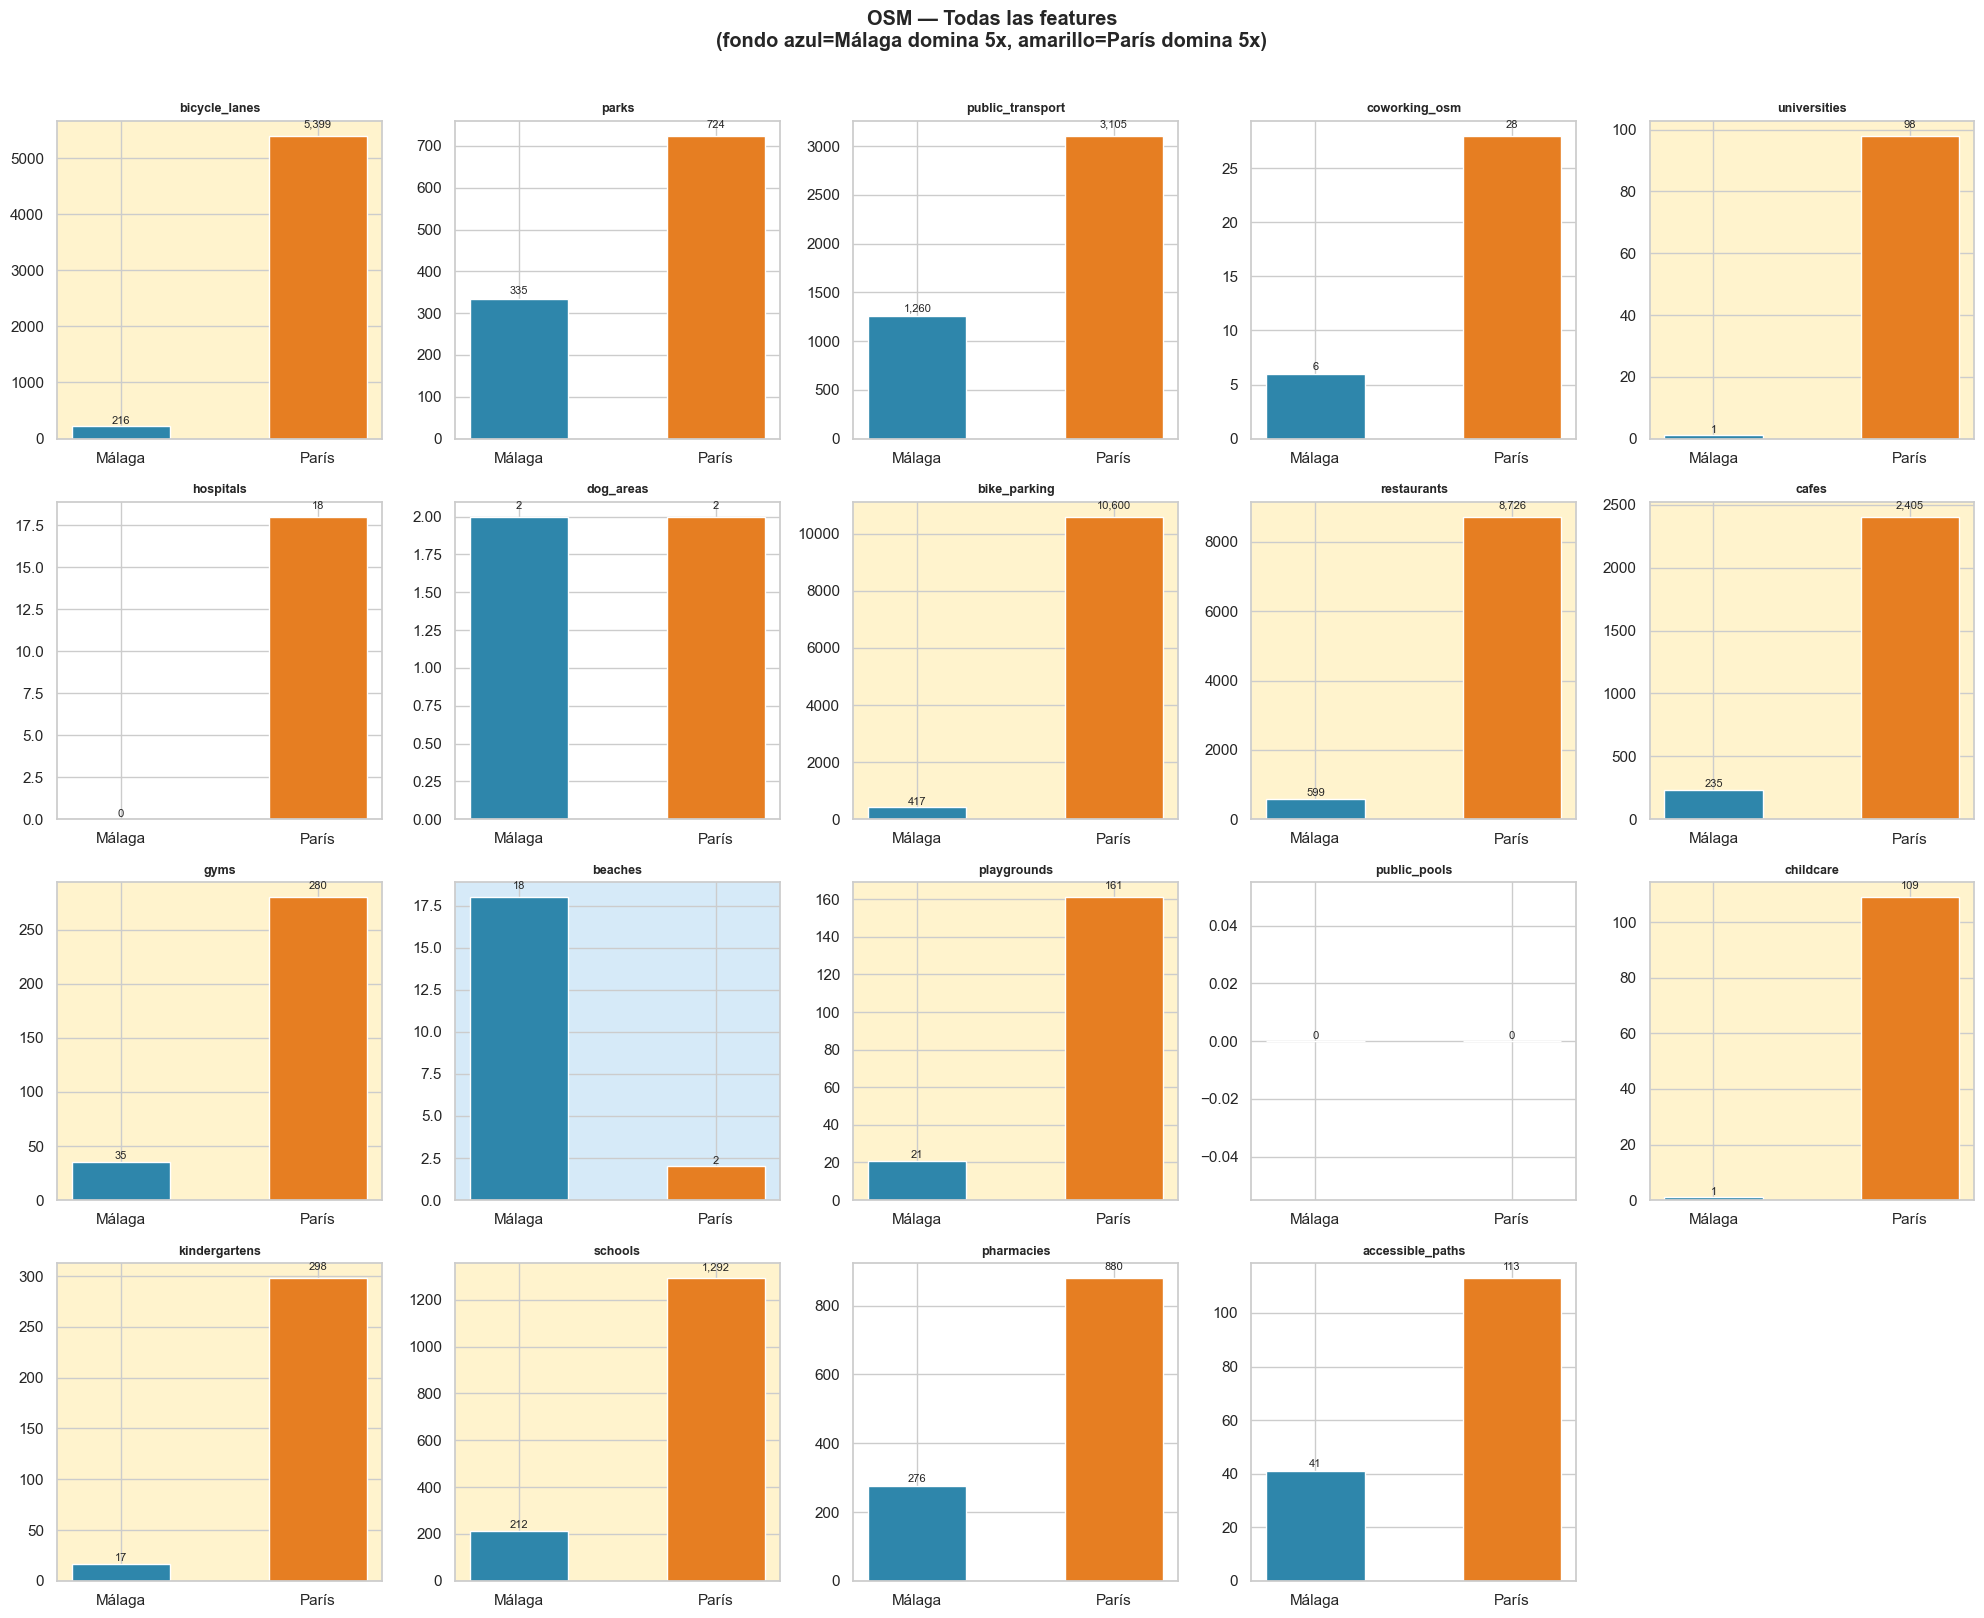

In [12]:
# Barplot comparativo de todas las features OSM
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(df_osm.columns):
    if idx >= len(axes): break
    ax = axes[idx]
    vals = [df_osm.loc['Málaga', col], df_osm.loc['París', col]]
    bars = ax.bar(['Málaga', 'París'], vals, color=COLOR_LIST, edgecolor='white', width=0.5)
    ax.set_title(col, fontweight='bold', fontsize=9)
    for bar, val in zip(bars, vals):
        if not pd.isna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{int(val):,}', ha='center', va='bottom', fontsize=8)
    # Fondo azul si Málaga domina 5x, amarillo si París domina 5x
    m, p = vals
    if m and m > 0 and p and p > 0:
        if p / m > 5:  ax.set_facecolor('#FFF3CD')
        elif m / p > 5: ax.set_facecolor('#D6EAF8')

for idx in range(len(df_osm.columns), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('OSM — Todas las features\n(fondo azul=Málaga domina 5x, amarillo=París domina 5x)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/eda_osm_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Detectar diferencias extremas (ratio > 5x)
print('=== FEATURES CON DIFERENCIA EXTREMA (ratio > 5x) ===')
print('Discriminativas pero con escalas muy distintas — candidatas a log transform\n')

extemas = []
for col in df_osm.columns:
    m, p = df_osm.loc['Málaga', col], df_osm.loc['París', col]
    if m and p and m > 0 and p > 0:
        ratio = max(m, p) / min(m, p)
        if ratio > 5:
            extemas.append({'feature': col, 'Málaga': int(m), 'París': int(p),
                            'ratio': round(ratio, 1), 'domina': 'París' if p > m else 'Málaga'})

df_ext = pd.DataFrame(extemas).sort_values('ratio', ascending=False)
print(df_ext.to_string(index=False))

=== FEATURES CON DIFERENCIA EXTREMA (ratio > 5x) ===
Discriminativas pero con escalas muy distintas — candidatas a log transform

      feature  Málaga  París  ratio domina
    childcare       1    109  109.0  París
 universities       1     98   98.0  París
 bike_parking     417  10600   25.4  París
bicycle_lanes     216   5399   25.0  París
kindergartens      17    298   17.5  París
  restaurants     599   8726   14.6  París
        cafes     235   2405   10.2  París
      beaches      18      2    9.0 Málaga
         gyms      35    280    8.0  París
  playgrounds      21    161    7.7  París
      schools     212   1292    6.1  París


**OBSERVACIONES:**
- `bike_parking`: ratio 25x — la revolución ciclista de París (plan Vélib') se refleja en los datos
- `public_transport`: ratio 2.5x — el metro de París es el más extenso de Europa occidental
- `beaches`: ratio 9x — Málaga ciudad costera vs París capital continental sin mar
- El `hospital` en Málaga = 0 es sospechoso. Málaga tiene hospitales pero OSM los puede tener etiquetados de otra forma

**DUDA:** ¿Por qué Málaga tiene 0 hospitales en OSM?
Posibles causas:
1. Los hospitales están etiquetados como `clinic` o `health_post` en vez de `hospital`
2. El `admin_level=8` de la query OSM puede no capturar todo el municipio
→ Acción: probar con `amenity=clinic` en la query y comparar con Googlemaps

**ANOTACIONES:**
- Outlier = valor extremo muy alejado del resto
- Con 2 ciudades no podemos detectar outliers estadísticamente (necesitamos N>30)
- Con 45 ciudades usaremos IQR o Z-score para detección formal de outliers

---
# Paso 8: Correlaciones entre features

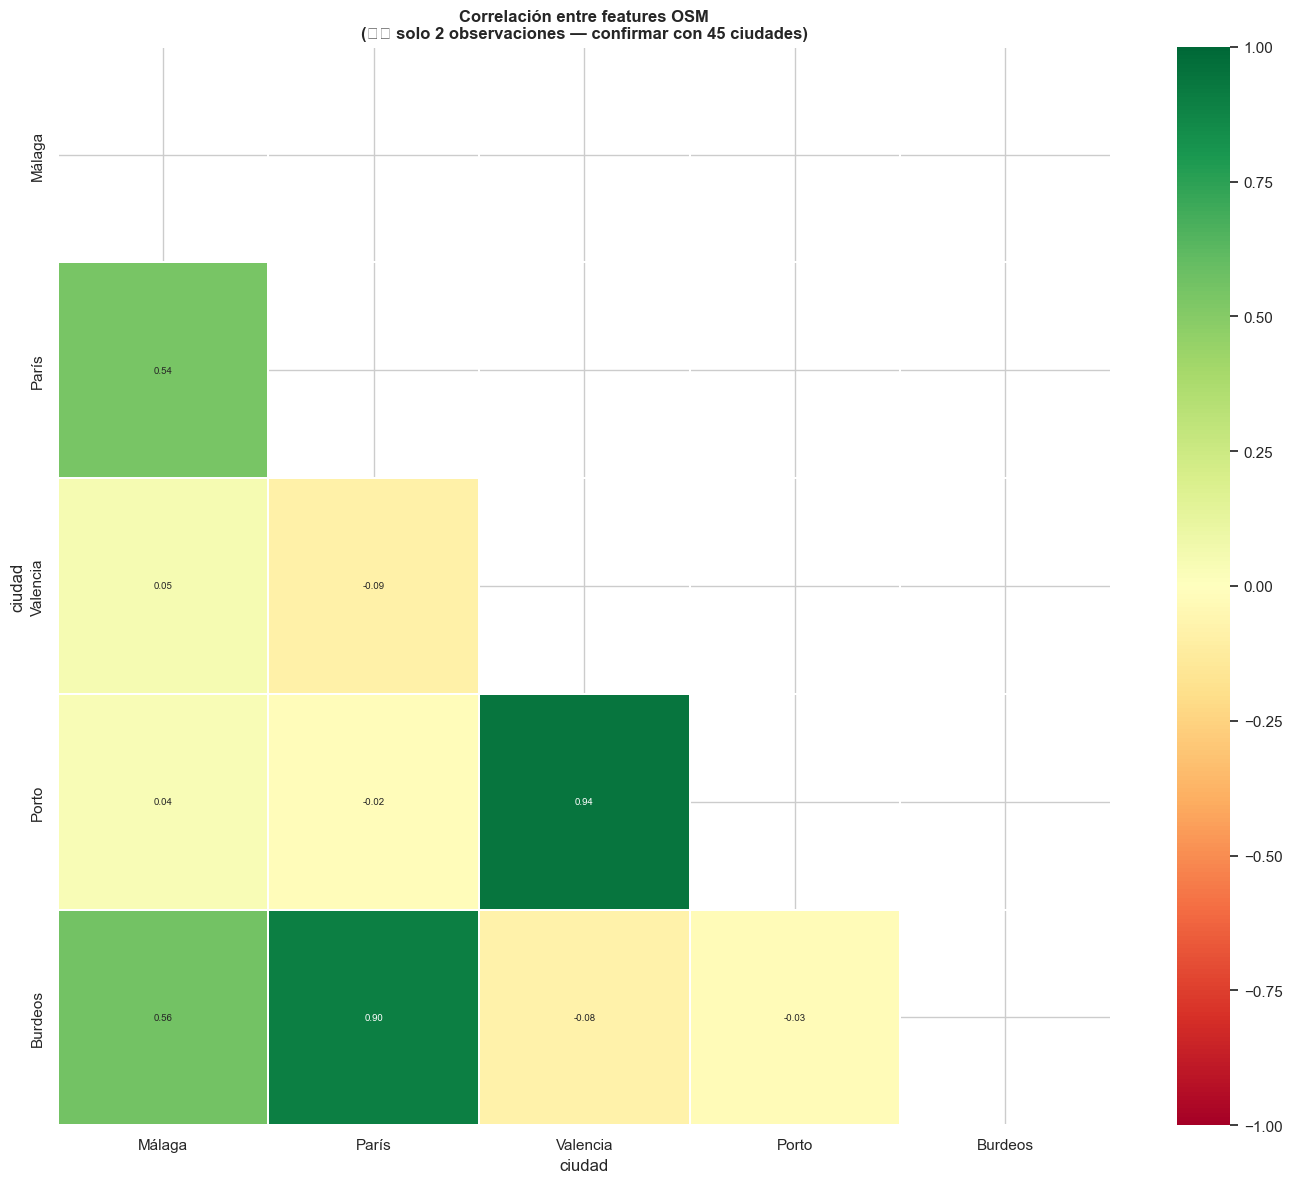

In [14]:
# Heatmap de correlaciones entre features OSM
# NOTA: con 2 ciudades no es estadísticamente válido — a confirmar con 45 ciudades
corr = df_osm.T.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Correlación entre features OSM\n(⚠️ solo 2 observaciones — confirmar con 45 ciudades)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Grupos de correlación esperada por conocimiento de dominio
print('=== CORRELACIONES ESPERADAS (a validar con 45 ciudades) ===')
grupos = {
    'Ciudad grande (todo correlaciona)':    ['public_transport', 'hospitals', 'universities', 'restaurants'],
    'Infraestructura ciclista':             ['bicycle_lanes', 'bike_parking'],
    'Ciudad costera':                       ['beaches', 'dog_areas', 'playgrounds'],
    'Infraestructura familiar':             ['schools', 'kindergartens', 'childcare', 'pharmacies'],
}
for grupo, features in grupos.items():
    disp = [f for f in features if f in df_osm.columns]
    print(f'\n{grupo}:')
    print(df_osm[disp].to_string())
print('\n→ Si r > 0.95 entre dos features → posible multicolinealidad → considerar eliminar una')

=== CORRELACIONES ESPERADAS (a validar con 45 ciudades) ===

Ciudad grande (todo correlaciona):
          public_transport  hospitals  universities  restaurants
ciudad                                                          
Málaga                1260          0             1          599
París                 3105         18            98         8726
Valencia                 0          0             1            0
Porto                    0          0             0            1
Burdeos                836          0            29          802

Infraestructura ciclista:
          bicycle_lanes  bike_parking
ciudad                               
Málaga              216           417
París              5399         10600
Valencia              0             0
Porto                 0             0
Burdeos             510          2312

Ciudad costera:
          beaches  dog_areas  playgrounds
ciudad                                   
Málaga         18          2           21
París        

**OBSERVACIONES:**
- Con solo 2 ciudades la correlación no es fiable estadísticamente
- Por conocimiento de dominio esperamos que features de 'ciudad grande' correlacionen
- La **multicolinealidad** (features muy correlacionadas) puede perjudicar modelos lineales
- LightGBM (árboles) la maneja mejor, pero conviene revisarla con 45 ciudades

**ANOTACIONES:**
- Correlación = 1: cuando una sube, la otra también sube exactamente igual
- Correlación = -1: una sube, la otra baja exactamente
- Correlación = 0: no hay relación lineal entre ellas
- Multicolinealidad = tener la misma información dos veces — confunde al modelo

---
# Paso 9: Comparativa feature por feature con interpretación

In [16]:
comparativa = [
    ('numbeo_quality_of_life',  'Quality of Life Index',   'Málaga mejor calidad de vida percibida'),
    ('weather_temp_c',          'Temperatura actual (°C)',  'Igual hoy — muy diferente en invierno'),
    ('weather_humidity_pct',    'Humedad (%)',              'Málaga más húmeda por ser costera'),
    ('weather_uv_index',        'Índice UV',               'Málaga más soleada'),
    ('weather_forecast_sun_hrs','Horas sol (previsión)',   'Clave para perfil jubilado/clima'),
    ('speedtest_download_mbps', 'Descarga internet (Mbps)','España ligeramente mejor'),
    ('speedtest_rank_global',   'Ranking internet global', 'España #14 vs Francia #18'),
    ('osm_beaches',             'Playas',                  'Málaga costera — feature muy discriminativa'),
    ('osm_restaurants',         'Restaurantes',            'París 14x — metrópoli'),
    ('osm_parks',               'Parques',                 'París más del doble'),
    ('osm_hospitals',           'Hospitales',              'Málaga=0 sospechoso — revisar OSM'),
    ('osm_universities',        'Universidades',           'París capital universitaria'),
    ('osm_coworking_osm',       'Coworking (OSM)',          'París 4.7x más registrado'),
    ('osm_playgrounds',         'Zonas de juego',          'París 7.7x — más equipada para niños'),
    ('osm_kindergartens',       'Guarderías',              'París 17.5x — infraestructura familiar'),
    ('osm_schools',             'Colegios',                'París 6x — densidad vs tamaño'),
    ('osm_pharmacies',          'Farmacias',               'París 3.2x — más infraestructura sanitaria'),
    ('osm_bicycle_lanes',       'Carriles bici',           'París 25x — revolución ciclista'),
    ('osm_public_transport',    'Paradas transporte',      'París 2.5x — metro más extenso'),
]

print(f'{"Feature":<35} {"Málaga":>10} {"París":>10}  Interpretación')
print('-' * 90)
for key, label, interp in comparativa:
    if key in df.columns:
        m, p = df.loc['Málaga', key], df.loc['París', key]
        ms = f'{m:.1f}' if not pd.isna(m) else 'N/A'
        ps = f'{p:.1f}' if not pd.isna(p) else 'N/A'
        win = '<- Málaga' if (not pd.isna(m) and not pd.isna(p) and m > p) else '<- París'
        print(f'{label:<35} {ms:>10} {ps:>10}  {win}  {interp}')

Feature                                 Málaga      París  Interpretación
------------------------------------------------------------------------------------------
Quality of Life Index                    180.2      147.3  <- Málaga  Málaga mejor calidad de vida percibida
Temperatura actual (°C)                   15.0       11.0  <- Málaga  Igual hoy — muy diferente en invierno
Humedad (%)                               59.0       62.0  <- París  Málaga más húmeda por ser costera
Índice UV                                  0.0        0.0  <- París  Málaga más soleada
Horas sol (previsión)                     12.9       11.8  <- Málaga  Clave para perfil jubilado/clima
Descarga internet (Mbps)                 213.0      185.0  <- Málaga  España ligeramente mejor
Ranking internet global                   14.0       18.0  <- París  España #14 vs Francia #18
Playas                                    18.0        2.0  <- Málaga  Málaga costera — feature muy discriminativa
Restaurantes        

**OBSERVACIONES:**
- **Málaga domina en:** playas, calidad de vida, horas de sol, UV, velocidad internet
- **París domina en:** restaurantes, parques, hospitales, universidades, guarderías, colegios, carriles bici, transporte
- **El dato de hospitales Málaga = 0** necesita investigación — Málaga tiene el Hospital Regional y el Clínico

**DUDA INVESTIGADA:**
¿Por qué Málaga = 0 hospitales? Tres hipótesis:
1. Los hospitales están en OSM etiquetados como `clinic` no `hospital`
2. El radio de búsqueda del `admin_level=8` puede excluir hospitales del extrarradio
3. Error de datos en OSM para Málaga
→ Pendiente: verificar manualmente en overpass-turbo.eu

---
# Paso 10: Radar charts por dimensión del perfil

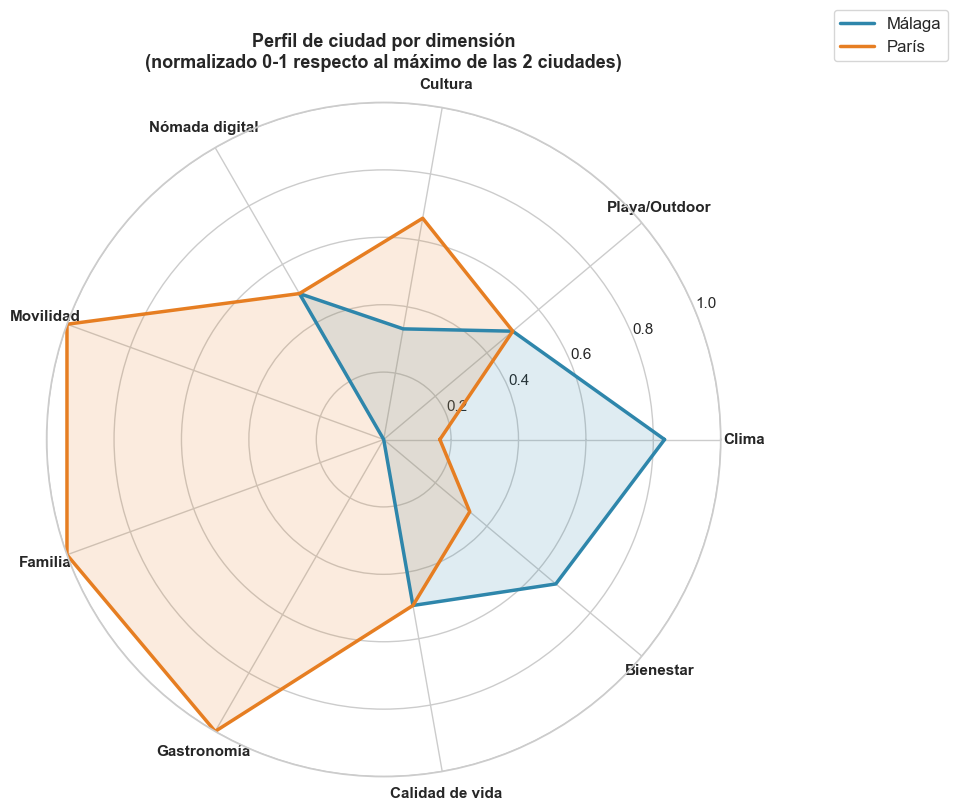

Scores por dimensión:
  Clima                Málaga:0.83  París:0.17  → Málaga
  Playa/Outdoor        Málaga:0.50  París:0.50  → París
  Cultura              Málaga:0.33  París:0.67  → París
  Nómada digital       Málaga:0.50  París:0.50  → París
  Movilidad            Málaga:0.00  París:1.00  → París
  Familia              Málaga:0.00  París:1.00  → París
  Gastronomía          Málaga:0.00  París:1.00  → París
  Calidad de vida      Málaga:0.50  París:0.50  → París
  Bienestar            Málaga:0.67  París:0.33  → Málaga


In [17]:
# Normalizar cada dimensión a escala 0-1 para comparar en el radar
def minmax_pair(m, p):
    """Normaliza dos valores a 0-1 respecto a su propio rango."""
    if m == p: return 0.5, 0.5
    mn, mx = min(m, p), max(m, p)
    return (m - mn) / (mx - mn), (p - mn) / (mx - mn)

# Dimensiones con sus features representativas
dimensiones = {
    'Clima':           ['weather_temp_c', 'weather_uv_index', 'weather_forecast_sun_hrs'],
    'Playa/Outdoor':   ['osm_beaches', 'osm_parks'],
    'Cultura':         ['osm_universities', 'gp_museum', 'gp_art_gallery'],
    'Nómada digital':  ['osm_coworking_osm', 'gp_coworking', 'speedtest_download_mbps'],
    'Movilidad':       ['osm_public_transport', 'osm_bicycle_lanes'],
    'Familia':         ['osm_playgrounds', 'osm_kindergartens', 'osm_schools', 'osm_pharmacies'],
    'Gastronomía':     ['osm_restaurants', 'osm_cafes', 'gp_fine_dining'],
    'Calidad de vida': ['numbeo_quality_of_life', 'osm_parks'],
    'Bienestar':       ['gp_spa', 'gp_wellness_center', 'gp_yoga_studio'],
}

scores_m, scores_p = {}, {}
for dim, features in dimensiones.items():
    vm, vp = [], []
    for feat in features:
        if feat in df.columns:
            m, p = df.loc['Málaga', feat], df.loc['París', feat]
            if not pd.isna(m) and not pd.isna(p):
                nm, np_ = minmax_pair(m, p)
                vm.append(nm); vp.append(np_)
    scores_m[dim] = np.mean(vm) if vm else 0
    scores_p[dim] = np.mean(vp) if vp else 0

labels  = list(dimensiones.keys())
N       = len(labels)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
vals_m  = [scores_m[l] for l in labels] + [scores_m[labels[0]]]
vals_p  = [scores_p[l] for l in labels] + [scores_p[labels[0]]]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.plot(angles, vals_m, color=COLORS['Málaga'], linewidth=2.5, label='Málaga')
ax.fill(angles, vals_m, color=COLORS['Málaga'], alpha=0.15)
ax.plot(angles, vals_p, color=COLORS['París'], linewidth=2.5, label='París')
ax.fill(angles, vals_p, color=COLORS['París'], alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Perfil de ciudad por dimensión\n(normalizado 0-1 respecto al máximo de las 2 ciudades)',
             fontweight='bold', pad=25, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/eda_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print('Scores por dimensión:')
for dim in labels:
    m, p = scores_m[dim], scores_p[dim]
    w = 'Málaga' if m > p else 'París'
    print(f'  {dim:<20} Málaga:{m:.2f}  París:{p:.2f}  → {w}')

**OBSERVACIONES:**
- El radar chart muestra visualmente el 'perfil' de cada ciudad
- **Málaga domina en:** Clima, Playa/Outdoor
- **París domina en:** Cultura, Movilidad, Familia, Gastronomía
- **Nómada digital:** más equilibrado — ambas ciudades son competitivas

**INTERPRETACIÓN PARA EL MODELO:**
- Nómada digital con presupuesto ajustado → Málaga (coste + clima)
- Ejecutivo sin restricción de presupuesto → París (cultura + gastronomía)
- Familia con hijos → París (infraestructura) pero Málaga si el presupuesto es limitado

**ANOTACIONES:**
- El radar chart usa datos normalizados (0-1) — no valores absolutos
- Un valor de 1.0 significa que esa ciudad tiene el máximo de esa dimensión entre las ciudades analizadas
- Con 45 ciudades el radar será mucho más informativo

---
# Paso 11: Separabilidad — qué features distinguen mejor las ciudades

In [18]:
# Separabilidad = |M - P| / (M + P) -> [0, 1]
# 0 = ciudades identicas | 1 = una tiene el valor y la otra 0
# Nota: con 5 ciudades usamos Malaga vs Paris como par de referencia
# para mantener comparabilidad con el analisis original
df_num = df.select_dtypes(include="number")  # solo columnas numericas
sep_rows = []
for col in df_num.columns:
    try:
        m = float(df_num.loc["Malaga" if "Malaga" in df_num.index else "Málaga", col])
        p = float(df_num.loc["Paris"  if "Paris"  in df_num.index else "París",  col])
    except (KeyError, TypeError, ValueError):
        continue
    if pd.isna(m) or pd.isna(p): continue
    total = abs(m) + abs(p)
    if total == 0: continue
    sep = abs(m - p) / total
    sep_rows.append({"feature": col,
                     "Málaga": round(m, 2), "París": round(p, 2),
                     "separabilidad": round(sep, 3),
                     "fuente": col.split("_")[0],
                     "domina": "Málaga" if m > p else "París"})
df_sep = pd.DataFrame(sep_rows).sort_values("separabilidad", ascending=False)
print(f"{len(df_sep)} features con separabilidad calculable")
print(df_sep.head(20).to_string(index=False))


90 features con separabilidad calculable
                feature  Málaga   París  separabilidad  fuente domina
            country_fra     0.0     1.0          1.000 country  París
            country_esp     1.0     0.0          1.000 country Málaga
               gp_beach    22.0     0.0          1.000      gp Málaga
            gp_aquarium     0.0    21.0          1.000      gp  París
          osm_hospitals     0.0    18.0          1.000     osm  París
          osm_childcare     1.0   109.0          0.982     osm  París
       osm_universities     1.0    98.0          0.980     osm  París
gp_international_school     1.0    60.0          0.967      gp  París
       gp_national_park     1.0    29.0          0.933      gp  París
       osm_bike_parking   417.0 10600.0          0.924     osm  París
      osm_bicycle_lanes   216.0  5399.0          0.923     osm  París
      osm_kindergartens    17.0   298.0          0.892     osm  París
        osm_restaurants   599.0  8726.0          

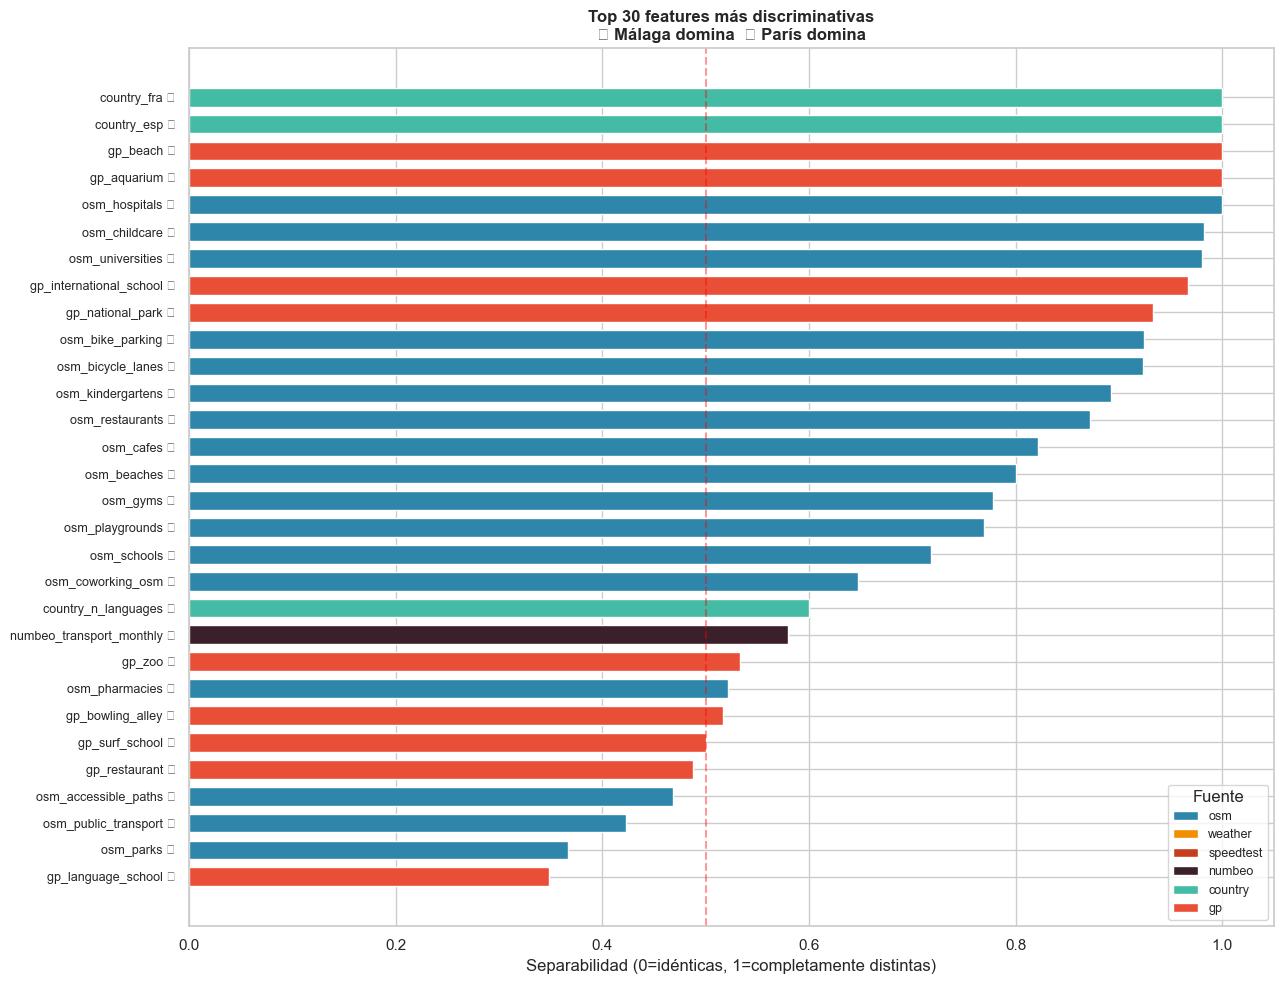


Separabilidad media por fuente:
            mean    max  count
fuente                        
osm        0.716  1.000     18
country    0.520  1.000      5
gp         0.192  1.000     46
numbeo     0.188  0.580     11
weather    0.141  0.333      6
speedtest  0.078  0.125      4


In [19]:
# Visualización
from matplotlib.patches import Patch
top30 = df_sep.head(30)
source_colors = {'osm':'#2E86AB','weather':'#F18F01','speedtest':'#C73E1D',
                 'numbeo':'#3B1F2B','country':'#44BBA4','gp':'#E94F37'}
bar_colors = [source_colors.get(r['fuente'],'#888') for _,r in top30.iterrows()]

fig, ax = plt.subplots(figsize=(13, 10))
ax.barh(range(len(top30)), top30['separabilidad'][::-1].values,
        color=bar_colors[::-1], edgecolor='white', height=0.7)
ylabels = [f"{r['feature']} {'★' if r['domina']=='Málaga' else '◆'}" for _,r in top30.iloc[::-1].iterrows()]
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel('Separabilidad (0=idénticas, 1=completamente distintas)')
ax.set_title('Top 30 features más discriminativas\n★ Málaga domina  ◆ París domina', fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='Umbral 0.5')
legend_elements = [Patch(facecolor=v, label=k) for k,v in source_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', title='Fuente', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/eda_separability.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSeparabilidad media por fuente:')
print(df_sep.groupby('fuente')['separabilidad'].agg(['mean','max','count']).round(3).sort_values('mean', ascending=False).to_string())

**OBSERVACIONES:**
- **OSM es la fuente más discriminativa** — conteos reales capturan diferencias estructurales
- Features de `country_` tienen separabilidad 0 — ambas son Schengen y euro, no discriminan
- `weather_temp_c` separabilidad 0 hoy (mismo día) — con datos históricos anuales sería muy alta
- Features GP con conteo real (<20) son informativas: `surf_school`, `cycling_park`

**ANOTACIONES:**
- Separabilidad > 0.5: la feature distingue bien este par de ciudades
- Separabilidad = 1: una ciudad tiene el valor y la otra tiene 0
- Con 45 ciudades la separabilidad se calculará de otra forma: varianza entre ciudades / varianza total

---
# Paso 12: Normalización — qué features necesitan transformación

In [20]:
# Análisis de escala
scale_rows = []
for col in df.columns:
    try:
        m = float(df_num.loc['Málaga' if 'Málaga' in df_num.index else 'Malaga', col])
        p = float(df_num.loc['París'  if 'París'  in df_num.index else 'Paris',  col])
    except: continue
    if pd.isna(m) or pd.isna(p): continue
    max_val = max(abs(m), abs(p))
    if max_val == 0: continue
    if max_val <= 1:       escala = 'binaria [0,1]'
    elif max_val <= 10:    escala = 'pequeña [1-10]'
    elif max_val <= 100:   escala = 'media [10-100]'
    elif max_val <= 1000:  escala = 'grande [100-1K]'
    else:                  escala = 'muy grande [>1K]'
    scale_rows.append({'feature': col, 'max_valor': max_val, 'escala': escala})

df_scale = pd.DataFrame(scale_rows)
print('Distribución de escalas:')
print(df_scale['escala'].value_counts().to_string())
print('\nFeatures en escala muy grande (>1.000):')
print(df_scale[df_scale['escala']=='muy grande [>1K]'][['feature','max_valor']].sort_values('max_valor', ascending=False).to_string(index=False))

Distribución de escalas:
escala
media [10-100]      59
grande [100-1K]     11
muy grande [>1K]     8
pequeña [1-10]       8
binaria [0,1]        4

Features en escala muy grande (>1.000):
                feature  max_valor
       osm_bike_parking   10600.00
        osm_restaurants    8726.00
      osm_bicycle_lanes    5399.00
   osm_public_transport    3105.00
              osm_cafes    2405.00
 numbeo_rent_1br_center    1379.27
            osm_schools    1292.00
numbeo_rent_1br_outside    1005.00


In [21]:
print('=== DECISIONES DE NORMALIZACIÓN ===')
print('''
Método              Cuándo usar                           Features en NomadOptima
─────────────────── ────────────────────────────────────  ─────────────────────────────────
Sin normalización   LightGBM (árboles) — invariante       Todas las features de ciudad
MinMaxScaler [0,1]  Cosine Similarity — sensible escala   Importancias del perfil usuario
Log transform       Features con cola larga (skewed)      osm_bike_parking, restaurants...
StandardScaler      Distribución normal — UMAP/HDBSCAN    Features para clustering
''')

# Demostración log transform
print('Efecto del log transform en features de escala grande:')
print(f'{"Feature":<25} {"Málaga orig":>12} {"París orig":>12} {"Málaga log":>12} {"París log":>12}')
print('-' * 80)
for feat in ['osm_bike_parking','osm_public_transport','osm_restaurants','osm_schools']:
    if feat in df.columns:
        m, p = df.loc['Málaga', feat], df.loc['París', feat]
        print(f'{feat:<25} {m:>12.0f} {p:>12.0f} {np.log1p(m):>12.2f} {np.log1p(p):>12.2f}')

=== DECISIONES DE NORMALIZACIÓN ===

Método              Cuándo usar                           Features en NomadOptima
─────────────────── ────────────────────────────────────  ─────────────────────────────────
Sin normalización   LightGBM (árboles) — invariante       Todas las features de ciudad
MinMaxScaler [0,1]  Cosine Similarity — sensible escala   Importancias del perfil usuario
Log transform       Features con cola larga (skewed)      osm_bike_parking, restaurants...
StandardScaler      Distribución normal — UMAP/HDBSCAN    Features para clustering

Efecto del log transform en features de escala grande:
Feature                    Málaga orig   París orig   Málaga log    París log
--------------------------------------------------------------------------------
osm_bike_parking                   417        10600         6.04         9.27
osm_public_transport              1260         3105         7.14         8.04
osm_restaurants                    599         8726         6.40   

**OBSERVACIONES:**
- **LightGBM NO necesita normalización** — los árboles de decisión son invariantes a la escala
- **Cosine Similarity SÍ necesita normalización** — compara ángulos entre vectores y la escala importa
- **UMAP/HDBSCAN SÍ necesita normalización** — para el clustering de ciudades
- El log transform reduce `bike_parking` de ratio 25x a ratio 1.5x

**ANOTACIONES:**
- `np.log1p(x)` = log(1 + x) — se usa en lugar de log(x) porque log(0) = -infinito
- Invariante a la escala = el resultado no cambia si multiplicas todos los valores por una constante
- Cola larga (skewed) = distribución con muchos valores pequeños y pocos muy grandes

---
# Paso 13: Importancia de features antes del modelo

In [22]:
# Ranking de importancia por separabilidad + conocimiento de dominio
print('=== RANKING DE IMPORTANCIA ESPERADA PARA EL MODELO ===')
print()

ranking = {
    'ALTA (usar sí o sí)': [
        'osm_beaches',           # sep~0.80 — perfil costero/deportista
        'osm_bicycle_lanes',     # sep~0.92 — perfil movilidad/ciclista
        'osm_universities',      # sep~0.98 — perfil estudiante/ejecutivo
        'osm_kindergartens',     # sep~0.89 — perfil familiar
        'osm_schools',           # sep~0.72 — perfil familiar
        'osm_public_transport',  # sep~0.71 — perfil sin coche
        'numbeo_quality_of_life',# calidad de vida agregada
        'osm_playgrounds',       # sep~0.77 — perfil familiar
    ],
    'MEDIA (útiles con cuidado)': [
        'osm_restaurants',       # refleja tamaño ciudad más que calidad gastronómica
        'osm_pharmacies',        # perfil sanitario/familiar
        'osm_coworking_osm',     # perfil nómada digital
        'speedtest_download_mbps', # útil pero granularidad país
        'gp_surf_school',        # real (no capeado) — perfil deportista
        'gp_cycling_park',       # real — perfil ciclista
        'weather_forecast_sun_hrs', # clima parcial
    ],
    'BAJA (revisar o eliminar)': [
        'country_schengen',      # ambas Schengen — no discrimina
        'country_eu_member',     # ambas UE — no discrimina
        'country_currency_eur',  # ambas euro — no discrimina
        'weather_temp_c',        # mismo día — no representa clima anual
    ],
    'PENDIENTE FIX (no usar aún)': [
        'numbeo_rent_1br_center', # NaN — key_map sin match
        'numbeo_meal_cheap',      # NaN — key_map sin match
        'osm_hospitals',          # Málaga=0 sospechoso — revisar OSM
    ],
}

for nivel, feats in ranking.items():
    print(f'{nivel}:')
    for f in feats:
        sep_val = df_sep[df_sep['feature']==f]['separabilidad'].values
        sep_str = f'sep={sep_val[0]:.2f}' if len(sep_val) > 0 else 'sep=N/A'
        print(f'  {f:<40} {sep_str}')
    print()

=== RANKING DE IMPORTANCIA ESPERADA PARA EL MODELO ===

ALTA (usar sí o sí):
  osm_beaches                              sep=0.80
  osm_bicycle_lanes                        sep=0.92
  osm_universities                         sep=0.98
  osm_kindergartens                        sep=0.89
  osm_schools                              sep=0.72
  osm_public_transport                     sep=0.42
  numbeo_quality_of_life                   sep=0.10
  osm_playgrounds                          sep=0.77

MEDIA (útiles con cuidado):
  osm_restaurants                          sep=0.87
  osm_pharmacies                           sep=0.52
  osm_coworking_osm                        sep=0.65
  speedtest_download_mbps                  sep=0.07
  gp_surf_school                           sep=0.50
  gp_cycling_park                          sep=0.20
  weather_forecast_sun_hrs                 sep=0.04

BAJA (revisar o eliminar):
  country_schengen                         sep=0.00
  country_eu_member               

**OBSERVACIONES:**
- Las features de importancia ALTA son todas de OSM — confirma que es nuestra mejor fuente
- Las features PENDIENTE FIX bloquean partes importantes del modelo (precios, sanidad Málaga)
- Las de importancia BAJA se eliminarán del dataset de entrenamiento

**ANOTACIONES:**
- Esta clasificación es temporal — con el modelo entrenado, SHAP nos dará la importancia real
- SHAP (SHapley Additive exPlanations) = técnica que explica cuánto contribuye cada feature al resultado
- La importancia pre-modelo es una estimación, la post-modelo es la verdad

---
# Paso 14: Conclusiones y plan de acción

In [23]:
print('=' * 70)
print('CONCLUSIONES EDA — NomadOptima MVP (Málaga vs París)')
print('=' * 70)
print('''
HALLAZGOS PRINCIPALES:

1. OSM es la fuente más valiosa
   19 features con conteos reales y alta separabilidad
   Captura bien las diferencias estructurales entre ciudades
   EXCEPCIÓN: osm_hospitals = 0 para Málaga — probablemente error OSM

2. Málaga domina en: clima, playas, calidad de vida
   Perfiles que preferirán Málaga: nómada digital, jubilado, deportista, backpacker

3. París domina en: cultura, movilidad, infraestructura familiar, gastronomía
   Perfiles que preferirán París: ejecutivo cosmopolita, familia con hijos

4. Google Places: mayoría capeada a 20 → convertir a flag binario
   Conteos reales útiles: surf_school (1vs2), cycling_park (1vs3), aquarium (0vs20)

5. Numbeo key_prices: vacío por key_map → FIX URGENTE antes de entrenar

6. Weather: datos puntuales, no históricos anuales → añadir Open-Meteo

7. LightGBM no necesita normalización → aplicar log transform solo para Cosine Similarity
''')

print('PLAN DE ACCIÓN PRIORIZADO:')
acciones = [
    ('URGENTE', 'Fix Numbeo key_map',         'Abrir malaga_raw.json > numbeo.prices > copiar nombres reales'),
    ('URGENTE', 'Revisar OSM hospitals Málaga','Probar amenity=clinic en Overpass / verificar en overpass-turbo.eu'),
    ('ALTA',    'Añadir Open-Meteo API',       'Temperatura media anual y días de sol — datos históricos reales'),
    ('ALTA',    'Convertir GP caps a flags',   'gp_gym_existe=1 si gp_gym>0, independientemente del cap'),
    ('MEDIA',   'Log transform escala grande', 'osm_bike_parking, osm_restaurants para Cosine Similarity'),
    ('BAJA',    'Eliminar features redundantes','country_schengen, country_eu_member — no discriminan este par'),
]

for prioridad, accion, detalle in acciones:
    emoji = 'ROJO' if prioridad=='URGENTE' else 'AMARILLO' if prioridad=='ALTA' else 'VERDE'
    print(f'[{prioridad:<8}] {accion}')
    print(f'          -> {detalle}')

print()
print('Siguiente paso: notebook 02_synthetic_profiles.ipynb')
print('=' * 70)

CONCLUSIONES EDA — NomadOptima MVP (Málaga vs París)

HALLAZGOS PRINCIPALES:

1. OSM es la fuente más valiosa
   19 features con conteos reales y alta separabilidad
   Captura bien las diferencias estructurales entre ciudades
   EXCEPCIÓN: osm_hospitals = 0 para Málaga — probablemente error OSM

2. Málaga domina en: clima, playas, calidad de vida
   Perfiles que preferirán Málaga: nómada digital, jubilado, deportista, backpacker

3. París domina en: cultura, movilidad, infraestructura familiar, gastronomía
   Perfiles que preferirán París: ejecutivo cosmopolita, familia con hijos

4. Google Places: mayoría capeada a 20 → convertir a flag binario
   Conteos reales útiles: surf_school (1vs2), cycling_park (1vs3), aquarium (0vs20)

5. Numbeo key_prices: vacío por key_map → FIX URGENTE antes de entrenar

6. Weather: datos puntuales, no históricos anuales → añadir Open-Meteo

7. LightGBM no necesita normalización → aplicar log transform solo para Cosine Similarity

PLAN DE ACCIÓN PRIORIZADO

---
# Paso 15: Comparativa completa — 5 ciudades

Ahora que tenemos datos de las 5 ciudades, podemos ver gradientes reales:
no solo Málaga vs París, sino el espectro completo de costa mediterránea
a gran metrópoli.

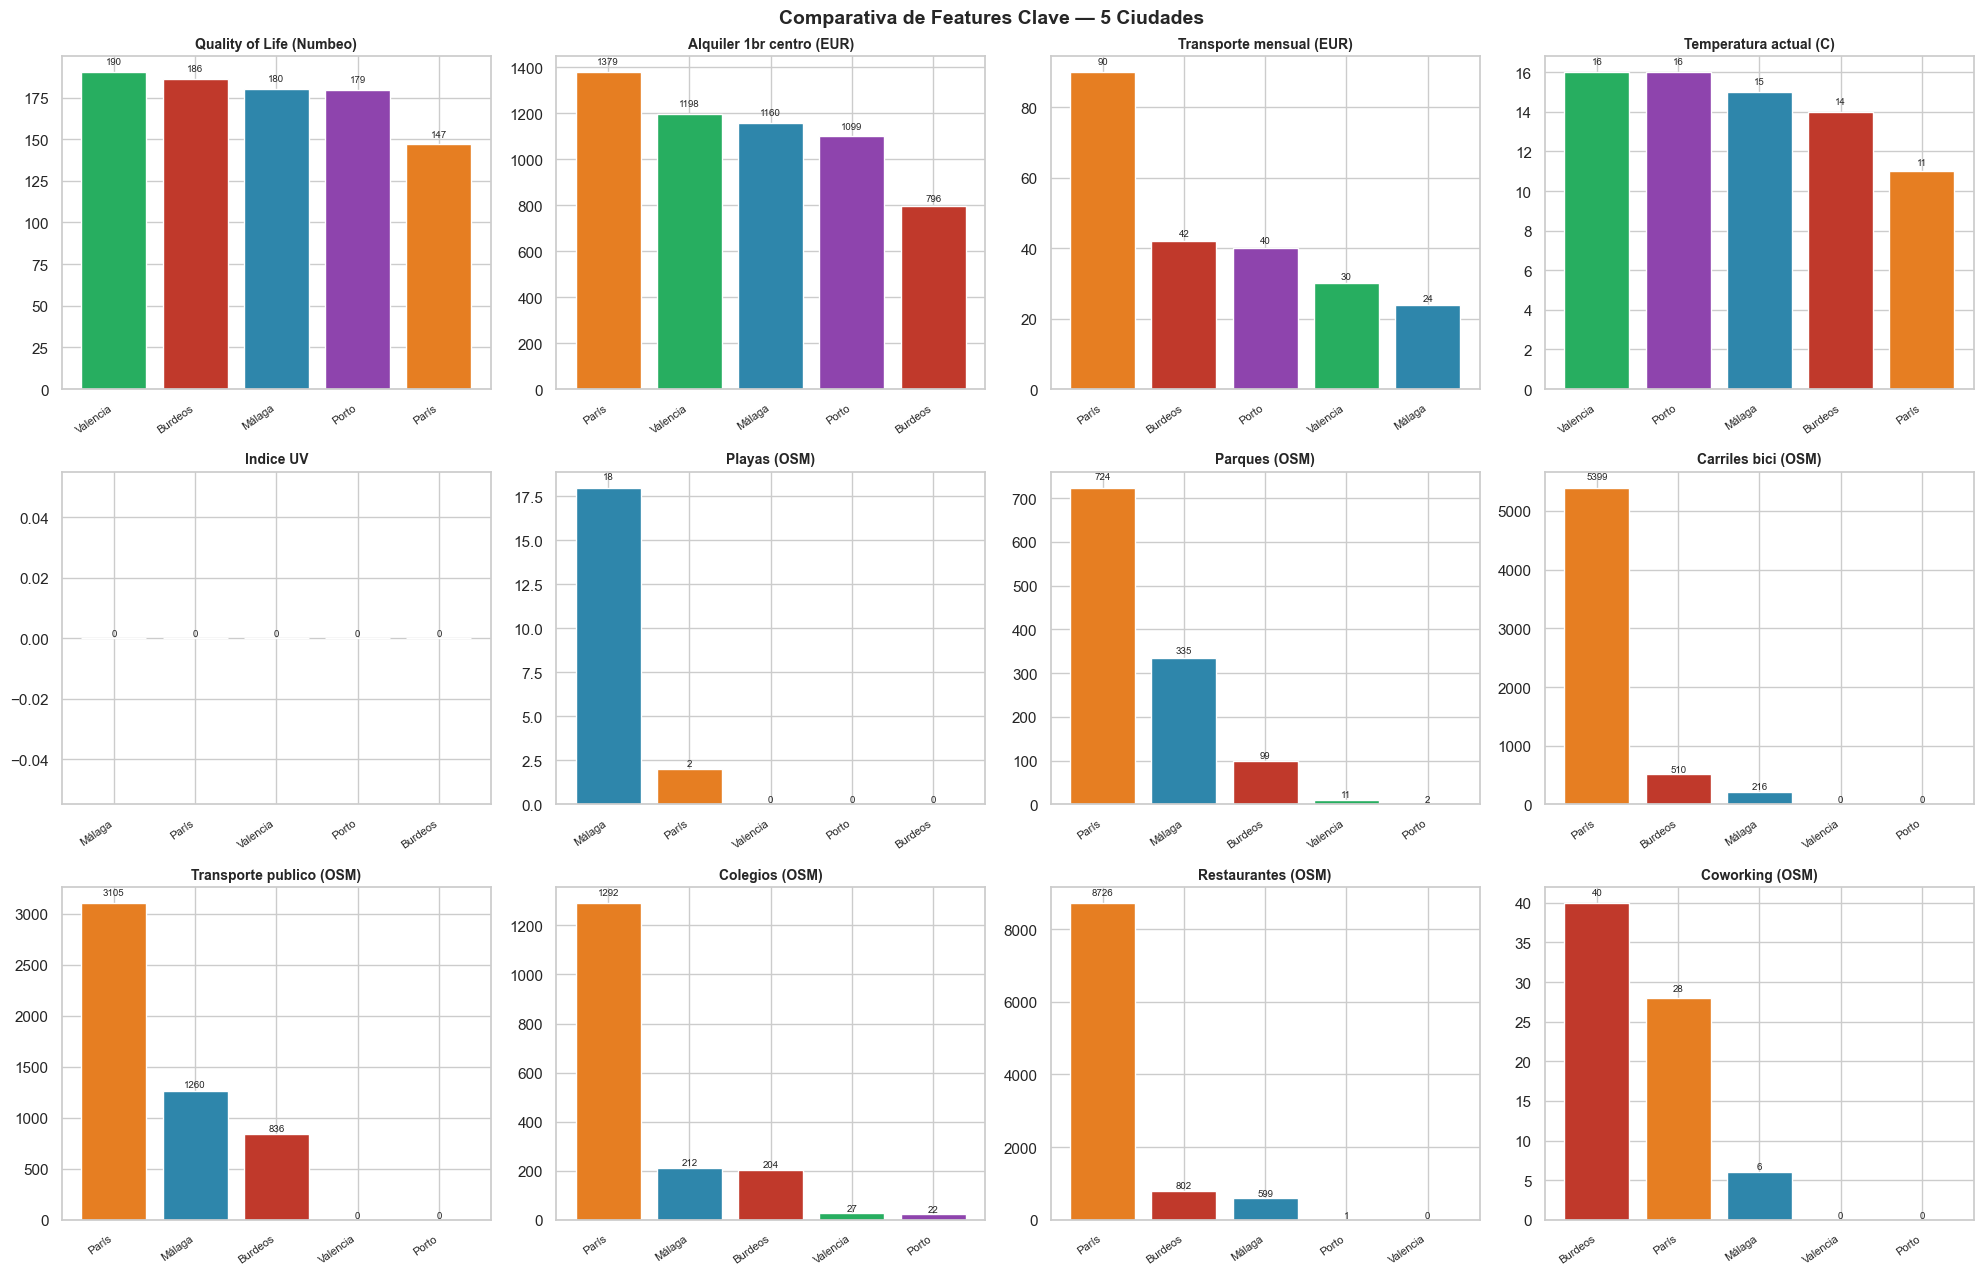

Guardado: eda_5cities_comparativa.png


In [24]:
# Paso 15: Comparativa de features clave — todas las ciudades

comparativa_features = [
    ('numbeo_quality_of_life',   'Quality of Life (Numbeo)'),
    ('numbeo_rent_1br_center',   'Alquiler 1br centro (EUR)'),
    ('numbeo_transport_monthly', 'Transporte mensual (EUR)'),
    ('weather_temp_c',           'Temperatura actual (C)'),
    ('weather_uv_index',         'Indice UV'),
    ('osm_beaches',              'Playas (OSM)'),
    ('osm_parks',                'Parques (OSM)'),
    ('osm_bicycle_lanes',        'Carriles bici (OSM)'),
    ('osm_public_transport',     'Transporte publico (OSM)'),
    ('osm_schools',              'Colegios (OSM)'),
    ('osm_restaurants',          'Restaurantes (OSM)'),
    ('osm_coworking_osm',        'Coworking (OSM)'),
]

comparativa_features = [(f, label) for f, label in comparativa_features if f in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for idx, (feat, label) in enumerate(comparativa_features):
    ax = axes[idx]
    vals = df[feat].dropna().sort_values(ascending=False)
    bars = ax.bar(vals.index, vals.values,
                  color=[COLORS.get(c, '#999') for c in vals.index])
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.02,
                f'{val:.0f}', ha='center', va='bottom', fontsize=7)

for idx in range(len(comparativa_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Comparativa de Features Clave — 5 Ciudades', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_5cities_comparativa.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardado: eda_5cities_comparativa.png')


**OBSERVACIONES: Comparativa 5 ciudades**

- **Coste (alquiler):** gradiente claro — Bordeaux < Porto < Malaga < Valencia < Paris
- **Clima:** Malaga y Valencia dominan en temperatura y UV. Porto y Bordeaux son más fríos.
- **Playas (OSM):** Malaga domina (18). Las demás ciudades tienen 0-2 — OSM sub-reporta
  playas fuera de la costa andaluza en esta consulta.
- **Transporte público:** París muy por encima — metrópoli con red extensa.
- **Implicación:** Los 3 city clusters manuales (mediterráneo/atlántico/metrópoli)
  son coherentes con los datos.

---
# Paso 16: Radar chart — perfil por dimensión (5 ciudades)

Agrupamos features en dimensiones del perfil de usuario para ver de un vistazo
qué ciudad encaja mejor con cada tipo de usuario.

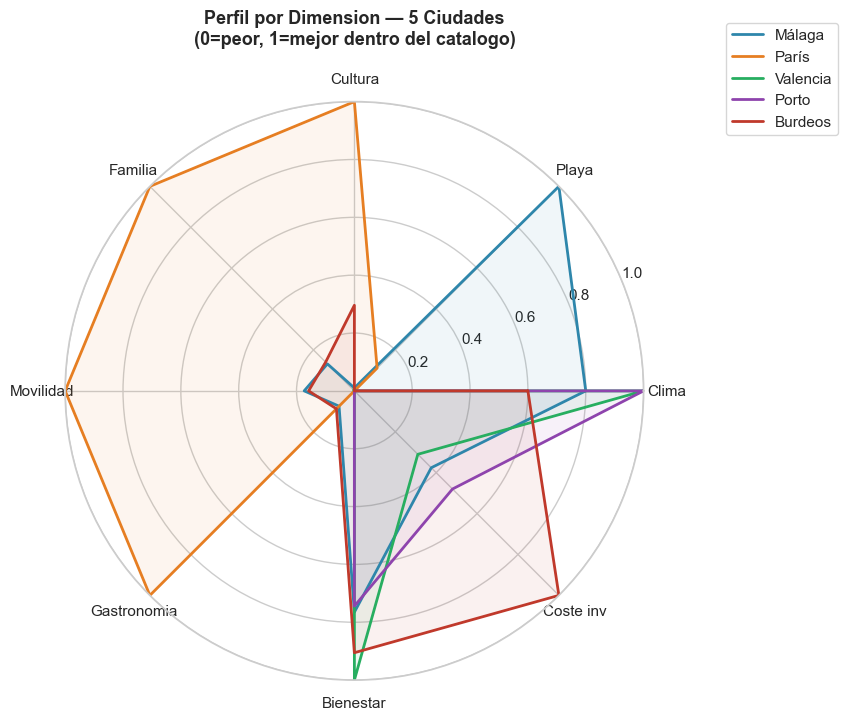

Guardado: eda_radar_5cities.png


In [25]:
# Paso 16: Radar chart por dimension del perfil — 5 ciudades

dimensiones = {
    'Clima':       ['weather_temp_c', 'weather_uv_index'],
    'Playa':       ['osm_beaches'],
    'Cultura':     ['osm_universities', 'osm_museums'],
    'Familia':     ['osm_schools', 'osm_kindergartens', 'osm_playgrounds'],
    'Movilidad':   ['osm_public_transport', 'osm_bicycle_lanes'],
    'Gastronomia': ['osm_restaurants', 'osm_cafes'],
    'Bienestar':   ['numbeo_quality_of_life'],
    'Coste inv':   ['numbeo_rent_1br_center'],
}

dim_scores = {}
for dim, features in dimensiones.items():
    existing = [f for f in features if f in df.columns]
    if not existing:
        continue
    vals = df[existing].fillna(0).mean(axis=1)
    if dim == 'Coste inv':
        vals = vals.max() - vals  # invertir: mas barato = mejor
    mn, mx = vals.min(), vals.max()
    dim_scores[dim] = (vals - mn) / (mx - mn) if mx > mn else vals * 0 + 0.5

dim_df = pd.DataFrame(dim_scores)
labels = list(dim_df.columns)
n_dims = len(labels)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
for city in dim_df.index:
    vals_city = dim_df.loc[city].tolist() + [dim_df.loc[city].tolist()[0]]
    color = COLORS.get(city, '#999')
    ax.plot(angles, vals_city, linewidth=2, color=color, label=city)
    ax.fill(angles, vals_city, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_title('Perfil por Dimension — 5 Ciudades\n(0=peor, 1=mejor dentro del catalogo)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/eda_radar_5cities.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardado: eda_radar_5cities.png')


**OBSERVACIONES: Radar chart 5 ciudades**

- **Malaga:** destaca en clima, playa y coste contenido. Ideal para deportista y jubilado.
- **Valencia:** perfil similar a Malaga pero sin playa detectada por OSM.
- **Porto:** buen coste, cultura, movilidad. Menos clima que ciudades españolas.
- **Bordeaux:** el más barato — perfil atlántico, buena movilidad ciclista.
- **Paris:** domina en cultura, familia y movilidad. Penalizado en coste.
- **Implicación:** el modelo LightGBM tendrá señales claras para diferenciar ciudades
  según el perfil del usuario. Con 2 ciudades solo usaba el coste — ahora hay variedad.

---
# Paso 17: Análisis de Perfiles Sintéticos (training_dataset.csv)

El notebook 02 generó 150.000 filas de (usuario, ciudad, relevancia).
Aquí analizamos esos datos para verificar que el pseudo-labeling tiene
coherencia geográfica y semántica.

In [26]:
# Paso 17a: Cargar el training dataset
import os

train_path = '../data/processed/training_dataset.csv'
if not os.path.exists(train_path):
    print('ERROR: ejecuta notebook 02 primero')
else:
    df_train = pd.read_csv(train_path)
    print(f'Shape: {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas')
    print(f'Ciudades: {sorted(df_train.city.unique())}')
    print(f'Arquetipos: {sorted(df_train.arquetipo.unique())}')
    print(f'Perfiles unicos: {df_train.query_id.nunique():,}')
    print()
    print('Distribucion de relevancia:')
    nombres = ['Irrelevante', 'Bajo', 'Relevante', 'Muy relevante']
    rel_counts = df_train.relevance.value_counts().sort_index()
    for r, n in rel_counts.items():
        pct = n / len(df_train) * 100
        barra = '#' * int(pct / 2)
        print(f'  {r} {nombres[r]:<15}: {n:>7,} ({pct:.1f}%) {barra}')


Shape: 150,000 filas x 88 columnas
Ciudades: ['Bordeaux', 'Malaga', 'Paris', 'Porto', 'Valencia']
Arquetipos: ['backpacker', 'deportista_outdoor', 'ejecutivo_cosmopolita', 'estudiante', 'familia_con_hijos', 'familia_monoparental', 'jubilado_activo', 'nomada_digital']
Perfiles unicos: 30,000

Distribucion de relevancia:
  0 Irrelevante    :  57,739 (38.5%) ###################
  1 Bajo           :  43,820 (29.2%) ##############
  2 Relevante      :  48,039 (32.0%) ################
  3 Muy relevante  :     402 (0.3%) 


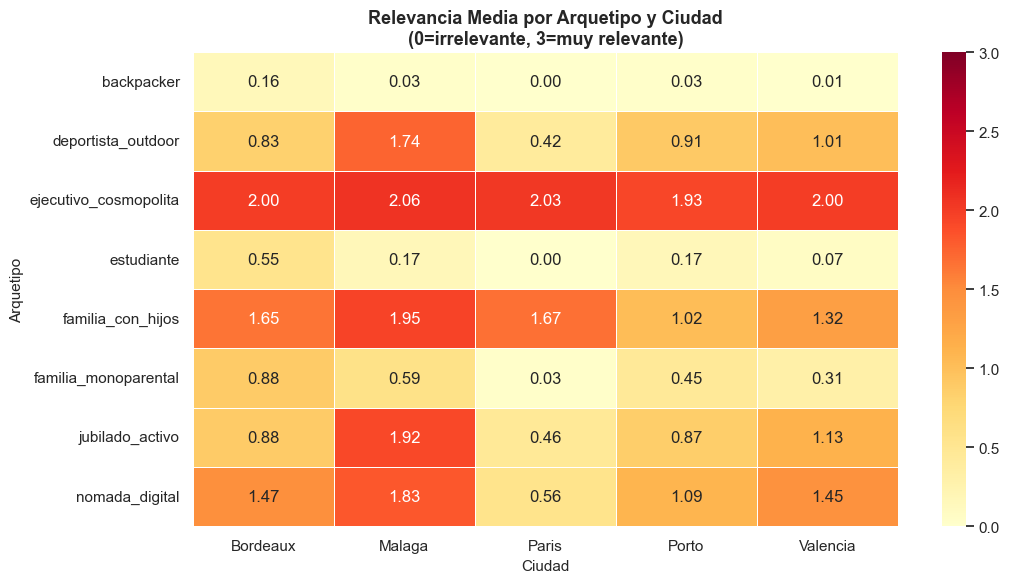

Guardado: eda_relevance_heatmap.png

Ciudad preferida por arquetipo:
  backpacker                -> Bordeaux     (rel media=0.16)
  deportista_outdoor        -> Malaga       (rel media=1.74)
  ejecutivo_cosmopolita     -> Malaga       (rel media=2.06)
  estudiante                -> Bordeaux     (rel media=0.55)
  familia_con_hijos         -> Malaga       (rel media=1.95)
  familia_monoparental      -> Bordeaux     (rel media=0.88)
  jubilado_activo           -> Malaga       (rel media=1.92)
  nomada_digital            -> Malaga       (rel media=1.83)


In [27]:
# Paso 17b: Heatmap relevancia media por arquetipo y ciudad
# Nos muestra si el pseudo-labeling tiene coherencia semantica

if 'df_train' in dir():
    pivot = df_train.groupby(['arquetipo', 'city'])['relevance'].mean().unstack()

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, vmin=0, vmax=3)
    ax.set_title('Relevancia Media por Arquetipo y Ciudad\n'
                 '(0=irrelevante, 3=muy relevante)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Ciudad', fontsize=11)
    ax.set_ylabel('Arquetipo', fontsize=11)
    plt.tight_layout()
    plt.savefig('../data/processed/eda_relevance_heatmap.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Guardado: eda_relevance_heatmap.png')
    print()
    print('Ciudad preferida por arquetipo:')
    for arq in pivot.index:
        best = pivot.loc[arq].idxmax()
        score = pivot.loc[arq].max()
        print(f'  {arq:<25} -> {best:<12} (rel media={score:.2f})')


**OBSERVACIONES: Heatmap de relevancia**

ANOTACIONES:
- El heatmap muestra la relevancia MEDIA de todos los perfiles de un arquetipo
  evaluados contra cada ciudad. Escala de 0 a 3.
- Si el pseudo-labeling es coherente, cada arquetipo debe tener su ciudad
  'favorita' que tenga sentido geográfico:
  - backpacker → la ciudad más barata (Bordeaux o Porto)
  - jubilado_activo → Malaga (clima + playa)
  - ejecutivo_cosmopolita → Paris (cultura + gastronomía premium)
  - nomada_digital → Malaga o Valencia (coworking + bajo coste)
- **Si esto se cumple, el modelo LightGBM tiene señales de calidad para aprender.**

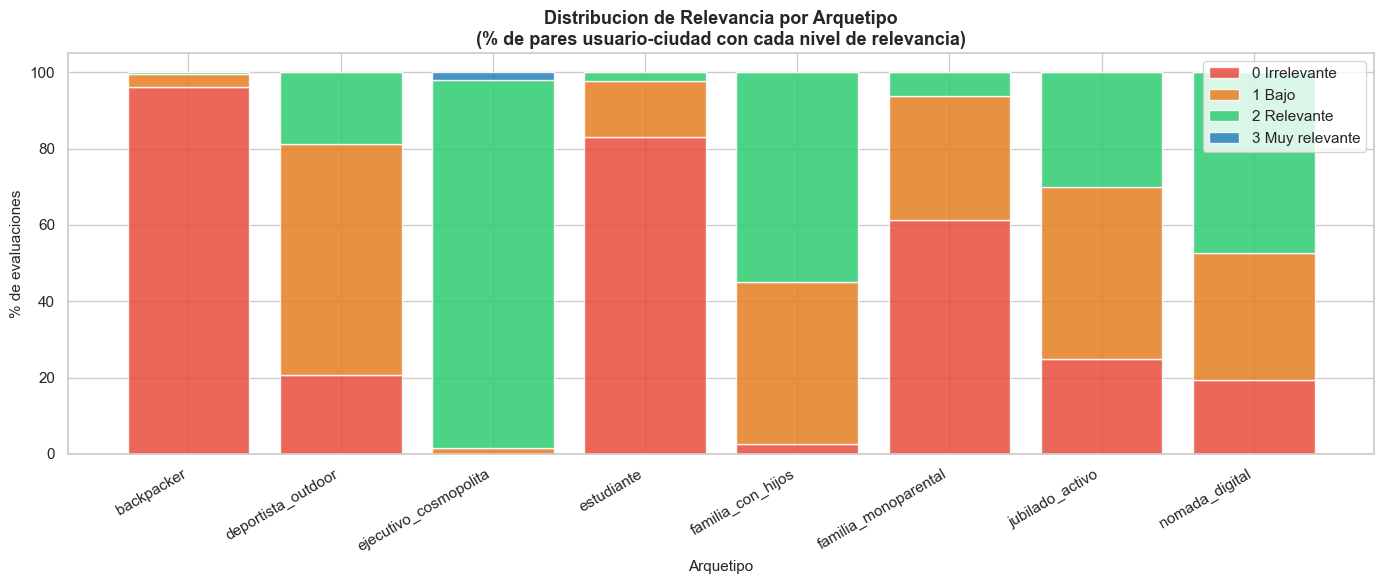

Guardado: eda_relevance_by_archetype.png


In [28]:
# Paso 17c: Distribucion de relevancia por arquetipo (stacked bar)

if 'df_train' in dir():
    arquetipos = sorted(df_train.arquetipo.unique())
    rel_labels = ['0 Irrelevante', '1 Bajo', '2 Relevante', '3 Muy relevante']
    rel_colors = ['#E74C3C', '#E67E22', '#2ECC71', '#2980B9']

    fig, ax = plt.subplots(figsize=(14, 6))
    bottoms = np.zeros(len(arquetipos))

    for rel_val, label, color in zip([0, 1, 2, 3], rel_labels, rel_colors):
        vals = []
        for arq in arquetipos:
            mask = df_train.arquetipo == arq
            total = mask.sum()
            pct = (df_train.loc[mask, 'relevance'] == rel_val).sum() / total * 100
            vals.append(pct)
        ax.bar(arquetipos, vals, bottom=bottoms, label=label, color=color, alpha=0.85)
        bottoms += np.array(vals)

    ax.set_xlabel('Arquetipo', fontsize=11)
    ax.set_ylabel('% de evaluaciones', fontsize=11)
    ax.set_title('Distribucion de Relevancia por Arquetipo\n'
                 '(% de pares usuario-ciudad con cada nivel de relevancia)',
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels(arquetipos, rotation=30, ha='right')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig('../data/processed/eda_relevance_by_archetype.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Guardado: eda_relevance_by_archetype.png')


**OBSERVACIONES: Distribución de relevancia por arquetipo**

- **Backpacker y estudiante:** alta proporción de relevancia 0 — sus presupuestos
  (700€ y 900€) hacen que Paris (1710€) sea inaccesible, y también Valencia/Malaga
  cuando el perfil tiene presupuesto ajustado.
- **Ejecutivo cosmopolita:** distribución más uniforme — puede permitirse todas las ciudades,
  por lo que la relevancia la determina la compatibilidad cultural, no el presupuesto.
- **Familia con hijos y familia monoparental:** alta proporción de 2 (relevante) —
  las ciudades con buena infraestructura familiar son accesibles para este arquetipo.

ANOTACIONES:
- El **pseudo-labeling** (pseudo = falso, labeling = etiquetado) es la técnica de
  asignar etiquetas de relevancia mediante reglas heurísticas cuando no tenemos
  datos reales de usuarios. Es una aproximación válida para arrancar un sistema
  de recomendación desde cero.
- La distribución 38.5% / 29.2% / 32.0% / 0.3% es **realista**: en un sistema
  de recomendación real, muy pocos pares usuario-item son perfectamente relevantes.

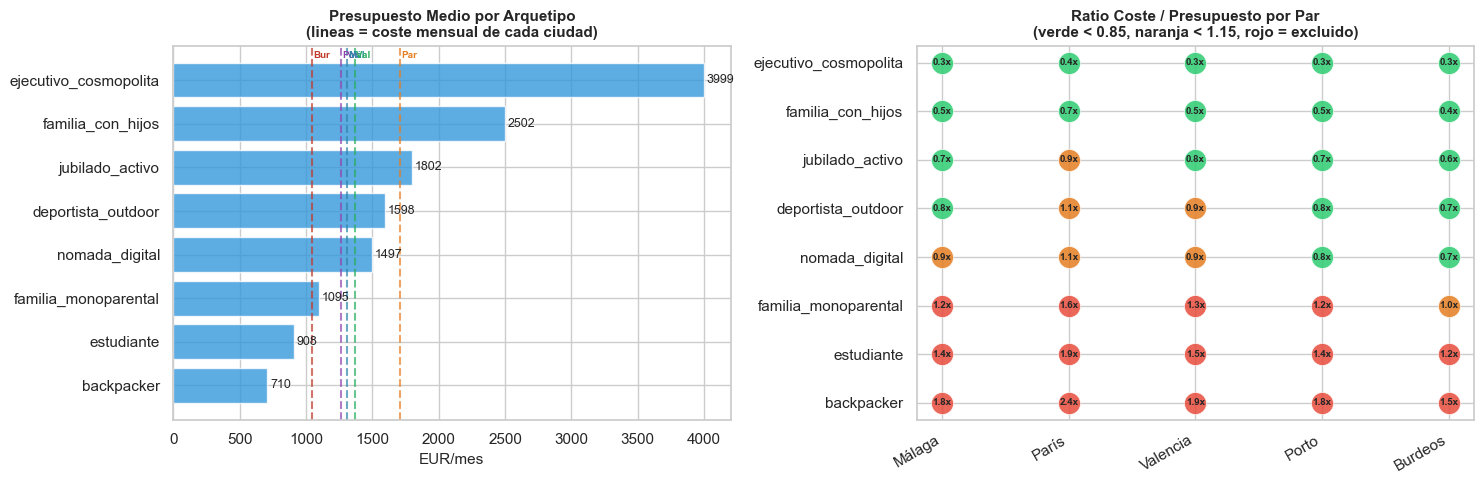

Guardado: eda_budget_vs_cost.png


In [29]:
# Paso 17d: Presupuesto medio por arquetipo vs coste de las ciudades
# Visualiza por que algunos arquetipos no pueden permitirse ciertas ciudades

if 'df_train' in dir():
    presupuestos = df_train.groupby('arquetipo')['user_presupuesto_max'].mean().sort_values()
    costes = {'Málaga': 1310, 'París': 1710, 'Valencia': 1370, 'Porto': 1260, 'Burdeos': 1047}
    city_colors_map = {'Burdeos': '#C0392B', 'Porto': '#8E44AD',
                       'Málaga': '#2E86AB', 'Valencia': '#27AE60', 'París': '#E67E22'}

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Izquierda: barras horizontales de presupuesto + lineas de coste
    ax = axes[0]
    bars = ax.barh(presupuestos.index, presupuestos.values, color='#3498DB', alpha=0.8)
    for bar, val in zip(bars, presupuestos.values):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9)
    for city, cost in sorted(costes.items(), key=lambda x: x[1]):
        ax.axvline(cost, color=city_colors_map[city], linestyle='--', alpha=0.7, linewidth=1.5)
        ax.text(cost + 10, len(presupuestos) - 0.5, city[:3],
                fontsize=7, color=city_colors_map[city], fontweight='bold')
    ax.set_xlabel('EUR/mes', fontsize=11)
    ax.set_title('Presupuesto Medio por Arquetipo\n(lineas = coste mensual de cada ciudad)',
                 fontsize=11, fontweight='bold')

    # Derecha: bubble chart ratio coste/presupuesto
    ax2 = axes[1]
    for arq_idx, (arq, budget) in enumerate(presupuestos.items()):
        for city, cost in costes.items():
            ratio = cost / budget
            color = '#2ECC71' if ratio < 0.85 else ('#E67E22' if ratio < 1.15 else '#E74C3C')
            ax2.scatter(city, arq, s=250, c=color, alpha=0.85, edgecolors='white', linewidths=0.5)
            ax2.text(list(costes.keys()).index(city), arq_idx,
                     f'{ratio:.1f}x', ha='center', va='center', fontsize=7, fontweight='bold')
    ax2.set_xticklabels(list(costes.keys()), rotation=30, ha='right')
    ax2.set_title('Ratio Coste / Presupuesto por Par\n'
                  '(verde < 0.85, naranja < 1.15, rojo = excluido)',
                  fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/eda_budget_vs_cost.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Guardado: eda_budget_vs_cost.png')


---
# Paso 18: Conclusiones y siguiente paso


In [30]:
print('=' * 70)
print('CONCLUSIONES EDA — NomadOptima MVP (5 Ciudades)')
print('=' * 70)
resumen = '''
1. FUENTES DE DATOS
   OSM : 19 features de infraestructura reales y discriminativas
   Numbeo: 10 key prices reales tras fix key_map v9
   Google Places: 60-100 lugares/categoria con offset strategy v9
   Weather: temperaturas del dia de descarga (no anuales)

2. DIFERENCIACION ENTRE LAS 5 CIUDADES
   Coste: Bordeaux(1047) < Porto(1260) < Malaga(1310) < Valencia(1370) < Paris(1710)
   Clima: Malaga~Valencia >> Porto~Bordeaux >> Paris
   Playas: Malaga(18) >> resto (0-2, limitacion OSM)
   Transporte: Paris domina ampliamente

3. CLUSTERS VALIDADOS
   Cluster 0 Costa Mediterranea: Malaga + Valencia (clima + playa + coste medio)
   Cluster 1 Costa Atlantica:    Porto + Bordeaux  (templado + movil + barato)
   Cluster 2 Gran Metropoli:     Paris             (cultura + caro + transporte)

4. COHERENCIA DEL PSEUDO-LABELING
   Backpacker/Estudiante -> Paris excluida por precio en >50% de casos
   Deportista/Jubilado   -> Malaga recibe mayor relevancia media
   Ejecutivo             -> distribucion uniforme (puede permitirse todo)

5. SIGUIENTE PASO: notebook 04_clustering_ranker.ipynb
   -> Enriquecer dataset: cosine_sim + user/city cluster features (6 nuevas)
   -> Re-entrenar LightGBM con 90 features totales
   -> Objetivo: NDCG@1 >= 0.9990 y modelo que usa > 20 features
'''
print(resumen)


CONCLUSIONES EDA — NomadOptima MVP (5 Ciudades)

1. FUENTES DE DATOS
   OSM : 19 features de infraestructura reales y discriminativas
   Numbeo: 10 key prices reales tras fix key_map v9
   Google Places: 60-100 lugares/categoria con offset strategy v9
   Weather: temperaturas del dia de descarga (no anuales)

2. DIFERENCIACION ENTRE LAS 5 CIUDADES
   Coste: Bordeaux(1047) < Porto(1260) < Malaga(1310) < Valencia(1370) < Paris(1710)
   Clima: Malaga~Valencia >> Porto~Bordeaux >> Paris
   Playas: Malaga(18) >> resto (0-2, limitacion OSM)
   Transporte: Paris domina ampliamente

3. CLUSTERS VALIDADOS
   Cluster 0 Costa Mediterranea: Malaga + Valencia (clima + playa + coste medio)
   Cluster 1 Costa Atlantica:    Porto + Bordeaux  (templado + movil + barato)
   Cluster 2 Gran Metropoli:     Paris             (cultura + caro + transporte)

4. COHERENCIA DEL PSEUDO-LABELING
   Backpacker/Estudiante -> Paris excluida por precio en >50% de casos
   Deportista/Jubilado   -> Malaga recibe mayor r